<a href="https://colab.research.google.com/github/No-Country-simulation/G9-FinanceAI-Team29/blob/main/RUTA/NOTEBOOK.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **FinSightAI**
## *Ver más allá de tus finanzas*

### Pipeline integral de Ciencia de Datos

**Proyecto desarrollado para el Hackathon Oracle Next Education (ONE) y No Country**

**Equipo:** TwentyNine Devs (G9 LATAM Team 29)

---

## **<u>Objetivo</u>**

**FinSightAI** es una plataforma de análisis financiero asistida por Inteligencia Artificial. Su propósito es ayudar a los usuarios a comprender sus ingresos, gastos, nivel de endeudamiento y capacidad de ahorro para tomar decisiones financieras más informadas.

El proyecto implementa un pipeline integral que abarca la exploración y preparación de datos, el procesamiento de variables financieras y textuales, la clasificación automática de transacciones, el análisis del perfil financiero, la generación de recomendaciones personalizadas y la serialización de los modelos para su integración mediante FastAPI con el backend de la aplicación.

FinSightAI no administra dinero ni funciona como billetera virtual. Su alcance se concentra en el análisis del comportamiento financiero y en la generación de información útil para el usuario.

---

## **<u>Objetivos del notebook</u>**

- Explorar y comprender la estructura de los datos.
- Limpiar y validar la información.
- Procesar variables financieras y textuales.
- Aplicar ingeniería de atributos.
- Clasificar automáticamente transacciones de gastos e ingresos.
- Analizar y predecir el perfil financiero de los usuarios.
- Evaluar los modelos mediante métricas apropiadas.
- Generar recomendaciones financieras explicables.
- Serializar los modelos y sus pipelines de preprocesamiento.
- Definir contratos de salida compatibles con una API REST.

---

## **<u>Alcance del MVP</u>**

El MVP se centra en cinco capacidades principales:

1. Clasificación automática de transacciones.
2. Análisis del comportamiento financiero.
3. Clasificación del perfil financiero.
4. Generación de recomendaciones personalizadas.
5. Integración de los modelos con el AI-Service desarrollado en FastAPI.


## **1. Importación de librerías y configuración**

In [1]:
from pathlib import Path
import json
import re
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

VERSION_NOTEBOOK = "10.0.0"
VERSION_MODELOS = "10.0.0"
RANDOM_STATE = 42

DATA_DIR = Path(".")
ARTIFACTS_DIR = Path("artefactos_financeai_v10")
MODELS_DIR = ARTIFACTS_DIR / "modelos"
PROCESSED_DIR = ARTIFACTS_DIR / "datos_procesados"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## **2. Carga reproducible de los datasets**

La siguiente celda busca los archivos CSV en el directorio actual, en `/content` y en `/mnt/data`. Cuando el notebook se ejecuta en Google Colab y los archivos no están disponibles, solicita su carga una sola vez.

El pipeline utiliza dos fuentes:

- `usuarios_sinteticos.csv`: información financiera consolidada por usuario.
- `transacciones_sinteticas.csv`: historial de ingresos y gastos.

El dataset de usuarios contiene únicamente variables necesarias para el análisis financiero y la clasificación del perfil. No se requieren columnas asociadas a billeteras, saldos operativos o movimientos internos de dinero.


In [2]:
def localizar_o_subir_csv(nombre_archivo: str) -> Path:
    rutas_posibles = [
        Path(nombre_archivo),
        Path("/content") / nombre_archivo,
        Path("/mnt/data") / nombre_archivo,
    ]

    for ruta in rutas_posibles:
        if ruta.exists():
            return ruta

    try:
        from google.colab import files
        print(f"No se encontró {nombre_archivo}. Seleccioná el archivo para subirlo.")
        archivos = files.upload()
        if nombre_archivo not in archivos:
            raise FileNotFoundError(
                f"Se esperaba el archivo {nombre_archivo}, pero no fue cargado."
            )
        return Path(nombre_archivo)
    except ImportError as exc:
        raise FileNotFoundError(
            f"No se encontró {nombre_archivo}. Colocalo junto al notebook."
        ) from exc


RUTA_USUARIOS = localizar_o_subir_csv("usuarios_sinteticos.csv")
RUTA_TRANSACCIONES = localizar_o_subir_csv("transacciones_sinteticas.csv")

usuarios_raw = pd.read_csv(RUTA_USUARIOS)
transacciones_raw = pd.read_csv(RUTA_TRANSACCIONES)

print("Usuarios:", usuarios_raw.shape)
print("Transacciones:", transacciones_raw.shape)

COLUMNAS_USUARIOS_REQUERIDAS = {
    "usuario_id",
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
    "frecuencia_ahorro",
    "perfil_financiero",
}

COLUMNAS_TRANSACCIONES_REQUERIDAS = {
    "transaction_id",
    "usuario_id",
    "fecha",
    "descripcion",
    "monto",
    "moneda",
    "tipo",
    "categoria",
    "recurrente",
    "medio_pago",
}

faltantes_usuarios = (
    COLUMNAS_USUARIOS_REQUERIDAS
    - set(usuarios_raw.columns)
)
faltantes_transacciones = (
    COLUMNAS_TRANSACCIONES_REQUERIDAS
    - set(transacciones_raw.columns)
)

if faltantes_usuarios:
    raise ValueError(
        "Faltan columnas requeridas en usuarios_sinteticos.csv: "
        f"{sorted(faltantes_usuarios)}"
    )

if faltantes_transacciones:
    raise ValueError(
        "Faltan columnas requeridas en transacciones_sinteticas.csv: "
        f"{sorted(faltantes_transacciones)}"
    )

print("Esquema de entrada validado correctamente.")


No se encontró usuarios_sinteticos.csv. Seleccioná el archivo para subirlo.


Saving transacciones_sinteticas.csv to transacciones_sinteticas.csv
Saving usuarios_sinteticos.csv to usuarios_sinteticos.csv
Usuarios: (1000, 11)
Transacciones: (74532, 11)
Esquema de entrada validado correctamente.


## **3. Exploración de Datos (EDA)**

El Análisis Exploratorio de Datos (Exploratory Data Analysis - EDA) constituye la primera etapa del proceso de Ciencia de Datos. Su objetivo es comprender la estructura, calidad e integridad de los datos antes de realizar el procesamiento de variables, la ingeniería de atributos y el entrenamiento de los modelos de Machine Learning.

En FinSightAI se utilizan dos conjuntos de datos sintéticos relacionados mediante la columna `usuario_id`:

- **usuarios_sinteticos.csv**: contiene información financiera general de cada usuario y las variables utilizadas para analizar su situación económica y construir su perfil financiero.
- **transacciones_sinteticas.csv**: contiene el historial de transacciones financieras de cada usuario, incluyendo descripciones, montos, fechas, tipos de transacción y categorías.

Durante esta etapa se analizan la estructura de ambos conjuntos de datos, los tipos de variables, la presencia de valores nulos o duplicados, las distribuciones principales y posibles inconsistencias que puedan afectar las etapas posteriores del proyecto.

El objetivo del EDA es garantizar que la información utilizada para el entrenamiento de los modelos sea consistente y de calidad, sirviendo como base para el procesamiento de variables financieras y textuales, la ingeniería de atributos, la clasificación automática de transacciones y el análisis del perfil financiero.

### **3.1 <u>Vista previa</u>**
En primer lugar, se realiza una inspección inicial de ambos conjuntos de datos para verificar su estructura, identificar las variables disponibles y obtener una visión general de la información contenida en cada uno.

Posteriormente, se genera un resumen de calidad de los datos que permite validar aspectos fundamentales como la cantidad de registros, número de variables, presencia de valores nulos y registros duplicados. Esta revisión constituye un paso esencial antes de iniciar el análisis exploratorio y el procesamiento de los datos.

In [3]:
display(usuarios_raw.head())
display(transacciones_raw.head())

print("\nColumnas de usuarios:")
print(usuarios_raw.columns.tolist())

print("\nColumnas de transacciones:")
print(transacciones_raw.columns.tolist())

print("\nDimensiones")
print(f"Usuarios: {usuarios_raw.shape}")
print(f"Transacciones: {transacciones_raw.shape}")

,usuario_id,ingreso_mensual,gasto_mensual_promedio,deuda_mensual,ahorro_mensual_estimado,porcentaje_gastos_ingreso,nivel_endeudamiento,porcentaje_ahorro_ingreso,frecuencia_ahorro,perfil_financiero,estado
0,USR0001,"3,229.8700","2,790.9400",548.3600,438.9300,86.4100,16.9800,13.5900,Media,En riesgo,ACTIVO
1,USR0002,"1,612.9500","1,095.2000",250.7700,517.7500,67.9000,15.5500,32.1000,Alta,En observación,ACTIVO
2,USR0003,"2,075.6400","1,979.8900",452.1500,95.7400,95.3900,21.7800,4.6100,Baja,En riesgo,ACTIVO
3,USR0004,"2,773.6200","1,453.7600","1,368.2300","1,319.8600",52.4100,49.3300,47.5900,Alta,En riesgo,ACTIVO
4,USR0005,"3,372.7100","2,630.7300",532.9800,741.9900,78.0000,15.8000,22.0000,Alta,En observación,ACTIVO


,transaction_id,usuario_id,fecha,descripcion,monto,moneda,tipo,categoria,subcategoria,medio_pago,recurrente
0,TX019999,USR0269,2026-05-26,Renta mensual,780.5400,USD,GASTO,Vivienda,Alquiler,Tarjeta de crédito,Sí
1,TX069718,USR0936,2025-11-23,abono de television local,69.8200,USD,GASTO,Servicios,Otros servicios,Transferencia bancaria,No
2,TX056667,USR0762,2026-02-02,remuneración,"5,593.4800",USD,INGRESO,Salario,Salario,Efectivo,Sí
3,TX046876,USR0631,2025-12-08,Depósito de haberes,"2,644.0700",USD,INGRESO,Salario,Salario,Depósito en cuenta,Sí
4,TX068053,USR0914,2025-09-09,Operacion Reintegro,114.7300,USD,INGRESO,Reintegro,Reintegro,Transferencia bancaria,No



Columnas de usuarios:
['usuario_id', 'ingreso_mensual', 'gasto_mensual_promedio', 'deuda_mensual', 'ahorro_mensual_estimado', 'porcentaje_gastos_ingreso', 'nivel_endeudamiento', 'porcentaje_ahorro_ingreso', 'frecuencia_ahorro', 'perfil_financiero', 'estado']

Columnas de transacciones:
['transaction_id', 'usuario_id', 'fecha', 'descripcion', 'monto', 'moneda', 'tipo', 'categoria', 'subcategoria', 'medio_pago', 'recurrente']

Dimensiones
Usuarios: (1000, 11)
Transacciones: (74532, 11)


In [4]:
resumen_calidad = pd.DataFrame({
    "Dataset": ["Usuarios", "Transacciones"],
    "Registros": [len(usuarios_raw), len(transacciones_raw)],
    "Variables": [usuarios_raw.shape[1], transacciones_raw.shape[1]],
    "Valores nulos": [
        int(usuarios_raw.isna().sum().sum()),
        int(transacciones_raw.isna().sum().sum()),
    ],
    "Duplicados": [
        int(usuarios_raw.duplicated().sum()),
        int(transacciones_raw.duplicated().sum()),
    ],
})

display(resumen_calidad)

,Dataset,Registros,Variables,Valores nulos,Duplicados
0,Usuarios,1000,11,0,0
1,Transacciones,74532,11,0,0


## **4. Limpieza y validación estructural**

Aunque los conjuntos de datos fueron generados sintéticamente, se aplican controles equivalentes a los que requeriría una fuente real. Se normalizan identificadores y textos, se convierten las variables numéricas y temporales, se eliminan inconsistencias y se valida la integridad referencial entre usuarios y transacciones.

Las validaciones principales comprueban:

- identificadores no vacíos y sin duplicados;
- fechas y montos válidos;
- montos positivos;
- categorías y tipos de transacción admitidos;
- ausencia de valores imposibles en ingresos, gastos, deuda y ahorro;
- correspondencia entre cada transacción y un usuario existente.

Estas verificaciones permiten detectar errores antes de iniciar la ingeniería de atributos y el entrenamiento de los modelos.


In [5]:
def normalizar_texto(texto: str) -> str:
    """Normaliza texto para facilitar su procesamiento posterior."""
    if pd.isna(texto):
        return ""

    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()


usuarios = usuarios_raw.copy()
transacciones = transacciones_raw.copy()


# =====================================================
# Dataset de usuarios
# =====================================================

usuarios["usuario_id"] = (
    usuarios["usuario_id"]
    .astype(str)
    .str.strip()
)

columnas_numericas_usuario = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
]

for columna in columnas_numericas_usuario:
    usuarios[columna] = pd.to_numeric(
        usuarios[columna],
        errors="coerce",
    )

for columna in ["frecuencia_ahorro", "perfil_financiero"]:
    usuarios[columna] = (
        usuarios[columna]
        .astype(str)
        .str.strip()
    )


# =====================================================
# Dataset de transacciones
# =====================================================

transacciones["transaction_id"] = (
    transacciones["transaction_id"]
    .astype(str)
    .str.strip()
)

transacciones["usuario_id"] = (
    transacciones["usuario_id"]
    .astype(str)
    .str.strip()
)

transacciones["fecha"] = pd.to_datetime(
    transacciones["fecha"],
    errors="coerce",
)

transacciones["monto"] = pd.to_numeric(
    transacciones["monto"],
    errors="coerce",
)

columnas_textuales = [
    "descripcion",
    "moneda",
    "tipo",
    "categoria",
    "recurrente",
    "medio_pago",
]

for columna in columnas_textuales:
    transacciones[columna] = (
        transacciones[columna]
        .astype(str)
        .str.strip()
    )

transacciones["tipo"] = transacciones["tipo"].str.upper()
transacciones["descripcion_limpia"] = (
    transacciones["descripcion"]
    .apply(normalizar_texto)
)


# =====================================================
# Validaciones de integridad
# =====================================================

if usuarios["usuario_id"].duplicated().any():
    raise ValueError("Se encontraron usuario_id duplicados.")

if transacciones["transaction_id"].duplicated().any():
    raise ValueError("Se encontraron transaction_id duplicados.")

if usuarios[columnas_numericas_usuario].isna().any().any():
    columnas_con_nulos = usuarios[
        columnas_numericas_usuario
    ].columns[
        usuarios[columnas_numericas_usuario]
        .isna()
        .any()
    ].tolist()

    raise ValueError(
        "Se detectaron valores numéricos inválidos en usuarios: "
        f"{columnas_con_nulos}"
    )

if transacciones[["fecha", "monto"]].isna().any().any():
    raise ValueError(
        "Se detectaron fechas o montos inválidos en transacciones."
    )

columnas_no_negativas = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "porcentaje_gastos_ingreso",
]

if (usuarios[columnas_no_negativas] < 0).any().any():
    raise ValueError(
        "Se detectaron valores negativos inválidos en usuarios."
    )

if (transacciones["monto"] <= 0).any():
    raise ValueError(
        "Los montos de las transacciones deben ser mayores que cero."
    )

ids_sin_usuario = (
    set(transacciones["usuario_id"])
    - set(usuarios["usuario_id"])
)

if ids_sin_usuario:
    raise ValueError(
        "Existen transacciones asociadas a usuarios inexistentes: "
        f"{sorted(ids_sin_usuario)[:10]}"
    )

tipos_validos = {"INGRESO", "GASTO"}
tipos_detectados = set(
    transacciones["tipo"]
    .dropna()
    .unique()
)

if not tipos_detectados.issubset(tipos_validos):
    raise ValueError(
        "El dataset solo debe contener INGRESO y GASTO. "
        f"Tipos detectados: {sorted(tipos_detectados)}"
    )

if (transacciones["descripcion_limpia"] == "").any():
    raise ValueError(
        "Se detectaron descripciones vacías después de la normalización."
    )

print("Limpieza y validaciones completadas correctamente.")
display(
    usuarios[columnas_numericas_usuario]
    .describe()
    .round(2)
)


Limpieza y validaciones completadas correctamente.


,ingreso_mensual,deuda_mensual,nivel_endeudamiento,gasto_mensual_promedio,ahorro_mensual_estimado,porcentaje_gastos_ingreso
count,"1,000.0000","1,000.0000","1,000.0000","1,000.0000","1,000.0000","1,000.0000"
mean,"3,863.7800",726.2500,19.3800,"2,593.1000","1,270.6800",67.4100
std,"1,422.1400",551.0700,12.8800,"1,108.1500",807.5800,14.5900
min,"1,246.5000",2.3500,0.0900,576.3400,-124.1900,28.1800
25%,"2,718.7900",334.4200,10.2200,"1,713.1600",653.0900,57.0700
50%,"3,779.6100",565.0800,15.9200,"2,492.3000","1,084.2400",68.0900
75%,"4,882.9300",964.9900,25.8800,"3,293.4200","1,721.3600",77.9900
max,"7,006.0500","3,059.1300",57.6000,"6,995.3400","4,591.9900",101.9100


## **5. Estadísticas descriptivas**

Las estadísticas descriptivas permiten obtener una visión general de la distribución y las características de las variables presentes en ambos conjuntos de datos.

Para las variables numéricas se presentan métricas como la media, desviación estándar, valores mínimos y máximos, así como los cuartiles. En el caso de las variables categóricas, se muestran indicadores como la cantidad de valores únicos, la categoría más frecuente y su frecuencia de aparición.

Este análisis proporciona una primera aproximación al comportamiento de los datos y facilita la identificación de posibles anomalías antes de continuar con la exploración visual y la ingeniería de atributos.


In [6]:
display(usuarios.describe(include="all").T)
display(transacciones.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
usuario_id,1000,1000,USR1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ingreso_mensual,"1,000.0000",NaN,NaN,NaN,"3,863.7812","1,422.1363","1,246.5000","2,718.7875","3,779.6100","4,882.9275","7,006.0500"
gasto_mensual_promedio,"1,000.0000",NaN,NaN,NaN,"2,593.1046","1,108.1463",576.3400,"1,713.1600","2,492.2950","3,293.4200","6,995.3400"
deuda_mensual,"1,000.0000",NaN,NaN,NaN,726.2538,551.0716,2.3500,334.4150,565.0850,964.9875,"3,059.1300"
ahorro_mensual_estimado,"1,000.0000",NaN,NaN,NaN,"1,270.6764",807.5758,-124.1900,653.0900,"1,084.2350","1,721.3550","4,591.9900"
porcentaje_gastos_ingreso,"1,000.0000",NaN,NaN,NaN,67.4101,14.5950,28.1800,57.0725,68.0850,77.9925,101.9100
nivel_endeudamiento,"1,000.0000",NaN,NaN,NaN,19.3826,12.8760,0.0900,10.2175,15.9200,25.8825,57.6000
porcentaje_ahorro_ingreso,"1,000.0000",NaN,NaN,NaN,32.5899,14.5950,-1.9100,22.0075,31.9150,42.9275,71.8200
frecuencia_ahorro,1000,4,Alta,787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
perfil_financiero,1000,3,En observación,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,74532,74532,TX040223,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
usuario_id,74532,1000,USR0725,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha,74532,NaN,NaN,NaN,2026-02-24 00:39:32.951215360,2025-08-27 00:00:00,2025-11-25 00:00:00,2026-02-26 00:00:00,2026-05-27 00:00:00,2026-08-27 00:00:00,NaN
descripcion,74532,8444,Deposito de haberes,610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monto,"74,532.0000",NaN,NaN,NaN,"1,039.5888",1.9500,119.5900,355.9600,"1,307.0550","11,813.8700","1,464.0633"
moneda,74532,1,USD,74532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo,74532,2,GASTO,60000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,74532,16,Vivienda,12547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subcategoria,74532,88,Salario,12000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medio_pago,74532,9,Tarjeta de crédito,12296,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **6. Distribución de categorías**

### **6.1 <u>Categoria Gastos.</u>**

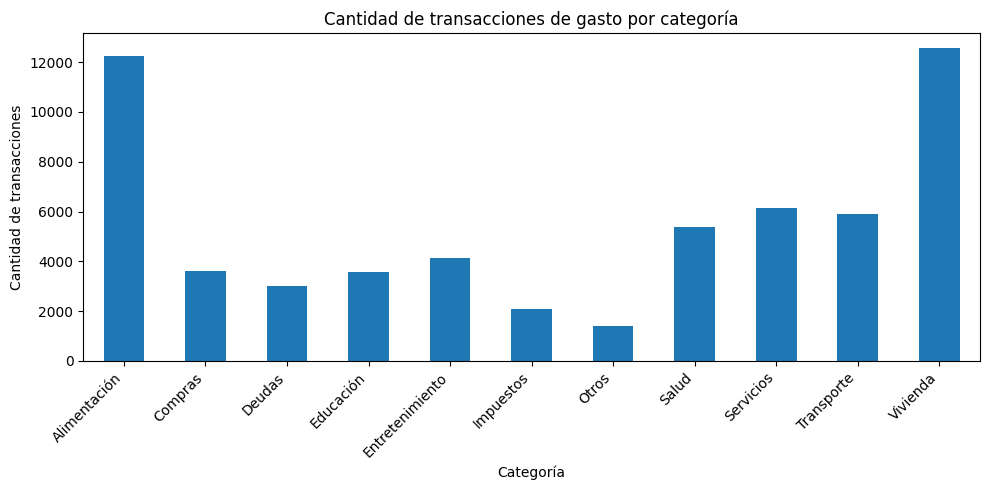

,cantidad
categoria,
Alimentación,12260
Compras,3611
Deudas,2999
Educación,3557
Entretenimiento,4124
Impuestos,2074
Otros,1409
Salud,5391
Servicios,6135


In [7]:
conteo_gastos = (
    transacciones
    .loc[transacciones["tipo"] == "GASTO", "categoria"]
    .value_counts()
    .sort_index()
)

ax = conteo_gastos.plot(
    kind="bar",
    figsize=(10, 5),
    title="Cantidad de transacciones de gasto por categoría",
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de transacciones")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(
    conteo_gastos.rename("cantidad").to_frame()
)

**Interpretación:** Las categorías de gasto presentan una distribución balanceada, con la misma cantidad de transacciones en cada clase. Al tratarse de un dataset sintético, esta distribución fue definida de manera controlada para evitar que el desbalance de clases afecte el entrenamiento y la evaluación del modelo de clasificación de transacciones. En un escenario con datos reales sería esperable encontrar una distribución más heterogénea, por lo que podrían requerirse técnicas como la ponderación de clases o estrategias de remuestreo.


### **6.2 <u>Categorías de ingresos</u>**

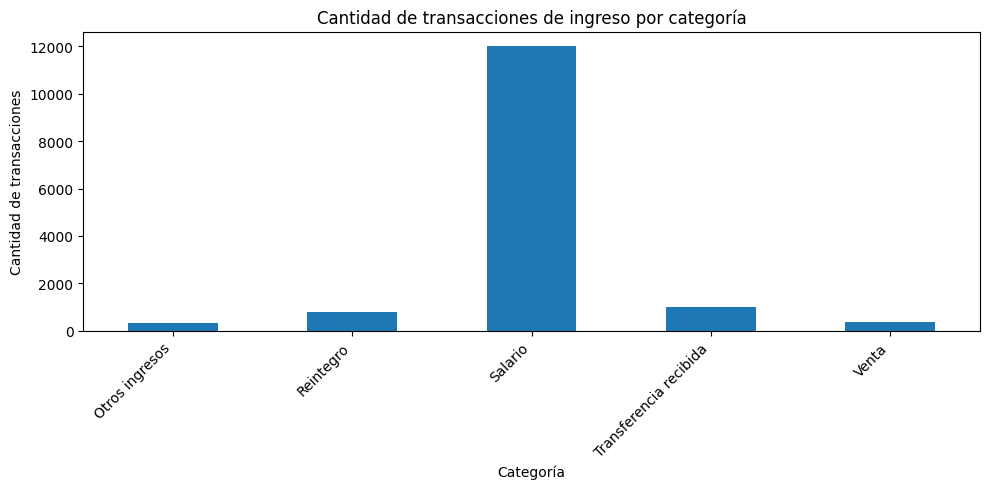

,cantidad
categoria,
Otros ingresos,349
Reintegro,806
Salario,12000
Transferencia recibida,1001
Venta,376


In [8]:
conteo_ingresos = (
    transacciones
    .loc[transacciones["tipo"] == "INGRESO", "categoria"]
    .value_counts()
    .sort_index()
)

ax = conteo_ingresos.plot(
    kind="bar",
    figsize=(10, 5),
    title="Cantidad de transacciones de ingreso por categoría",
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de transacciones")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(
    conteo_ingresos.rename("cantidad").to_frame()
)

***Interpretación***: La distribución de las categorías de ingreso refleja una mayor concentración en la categoría Salario, seguida por Transferencia recibida, Reintegro y Venta. Esta distribución fue definida de forma intencional durante la generación del dataset sintético para representar un escenario financiero más cercano al comportamiento esperado de un usuario promedio, donde el salario constituye la principal fuente de ingresos. Esta configuración proporciona un contexto adecuado para el análisis exploratorio y las etapas posteriores de Ingeniería de Atributos y Machine Learning.


## **7. Distribución de perfiles financieros**
En esta sección se analiza la distribución de la variable objetivo perfil_financiero, asignada a cada usuario a partir de sus características financieras. Conocer la frecuencia de cada perfil permite identificar posibles desbalances entre clases, aspecto relevante para el entrenamiento y la evaluación de los modelos de clasificación.

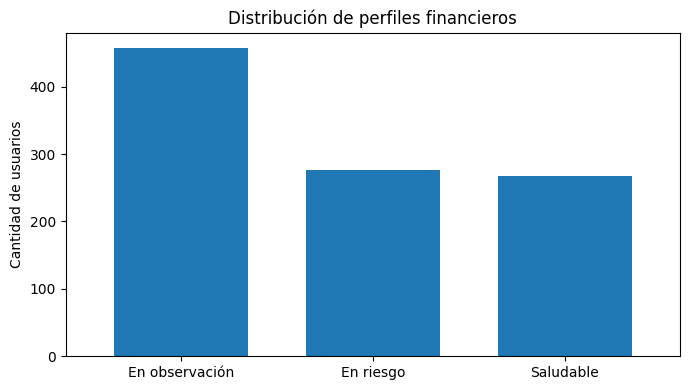

,usuarios,porcentaje (%),ingreso_promedio,gasto_promedio,deuda_promedio,ahorro_promedio,ratio_gasto,ratio_deuda,ratio_ahorro
perfil_financiero,,,,,,,,,
En observación,457,45.7000,"3,713.3900","2,643.3200",650.2600,"1,070.0700",0.7100,0.1800,0.2900
En riesgo,276,27.6000,"3,859.1500","3,023.0900","1,185.4800",836.0600,0.7800,0.3200,0.2200
Saludable,267,26.7000,"4,125.9700","2,062.6700",381.6100,"2,063.3100",0.5000,0.0900,0.5000


In [9]:
# ============================================
# Distribución y validación de perfiles financieros
# ============================================

# Crear ratios financieras (si aún no existen)
ingreso_seguro = usuarios["ingreso_mensual"].replace(0, np.nan)

usuarios["ratio_gasto_ingreso"] = (
    usuarios["gasto_mensual_promedio"] / ingreso_seguro
)

usuarios["ratio_deuda_ingreso"] = (
    usuarios["deuda_mensual"] / ingreso_seguro
)

usuarios["ratio_ahorro_ingreso"] = (
    usuarios["ahorro_mensual_estimado"] / ingreso_seguro
)

columnas_ratios = [
    "ratio_gasto_ingreso",
    "ratio_deuda_ingreso",
    "ratio_ahorro_ingreso",
]

usuarios[columnas_ratios] = (
    usuarios[columnas_ratios]
    .replace([np.inf, -np.inf], np.nan)
)

# ============================================
# Gráfico de distribución
# ============================================

fig, ax = plt.subplots(figsize=(7, 4))

(
    usuarios["perfil_financiero"]
    .value_counts()
    .plot(
        kind="bar",
        ax=ax,
        width=0.7,
    )
)

ax.set_title("Distribución de perfiles financieros")
ax.set_xlabel("")
ax.set_ylabel("Cantidad de usuarios")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================
# Resumen por perfil
# ============================================

resumen = (
    usuarios
    .groupby("perfil_financiero")
    .agg(
        usuarios=("usuario_id", "count"),
        ingreso_promedio=("ingreso_mensual", "mean"),
        gasto_promedio=("gasto_mensual_promedio", "mean"),
        deuda_promedio=("deuda_mensual", "mean"),
        ahorro_promedio=("ahorro_mensual_estimado", "mean"),
        ratio_gasto=("ratio_gasto_ingreso", "mean"),
        ratio_deuda=("ratio_deuda_ingreso", "mean"),
        ratio_ahorro=("ratio_ahorro_ingreso", "mean"),
    )
)

resumen["porcentaje (%)"] = (
    resumen["usuarios"]
    / resumen["usuarios"].sum()
    * 100
)

resumen = (
    resumen[
        [
            "usuarios",
            "porcentaje (%)",
            "ingreso_promedio",
            "gasto_promedio",
            "deuda_promedio",
            "ahorro_promedio",
            "ratio_gasto",
            "ratio_deuda",
            "ratio_ahorro",
        ]
    ]
    .round(2)
)

display(resumen)

**Interpretación:** La distribución de los perfiles financieros presenta un desbalance moderado entre las tres clases. El perfil Saludable concentra la mayor cantidad de usuarios, seguido por En observación y En riesgo.

Los perfiles se relacionan con indicadores de flujo mensual, como la proporción de gastos sobre ingresos, el nivel de endeudamiento y la capacidad de ahorro. El resumen por clase permite comprobar que las etiquetas representan comportamientos financieros diferenciados y proporciona una primera validación conceptual de la variable objetivo utilizada por el clasificador.


## **8. Análisis de montos y medios de pago**

### **8.1 <u>Gastos por categoría</u>**

,count,sum,mean,median,max
categoria,,,,,
Vivienda,12547,"13,239,222.6400","1,055.1704",882.5400,"11,813.8700"
Deudas,2999,"3,704,942.1500","1,235.3925","1,130.4600","8,735.4300"
Salud,5391,"2,819,562.1400",523.0128,424.3500,"6,182.2400"
Compras,3611,"2,416,720.0300",669.2661,578.4100,"5,962.5700"
Impuestos,2074,"2,043,470.6400",985.2800,895.3950,"6,872.6400"
Educación,3557,"1,873,884.7900",526.8161,435.6600,"5,065.8200"
Alimentación,12260,"1,395,141.7900",113.7962,91.0400,"1,005.3600"
Servicios,6135,"1,353,783.6100",220.6656,185.7700,"1,750.6200"
Transporte,5893,"1,328,883.5400",225.5020,86.9500,"4,915.5800"


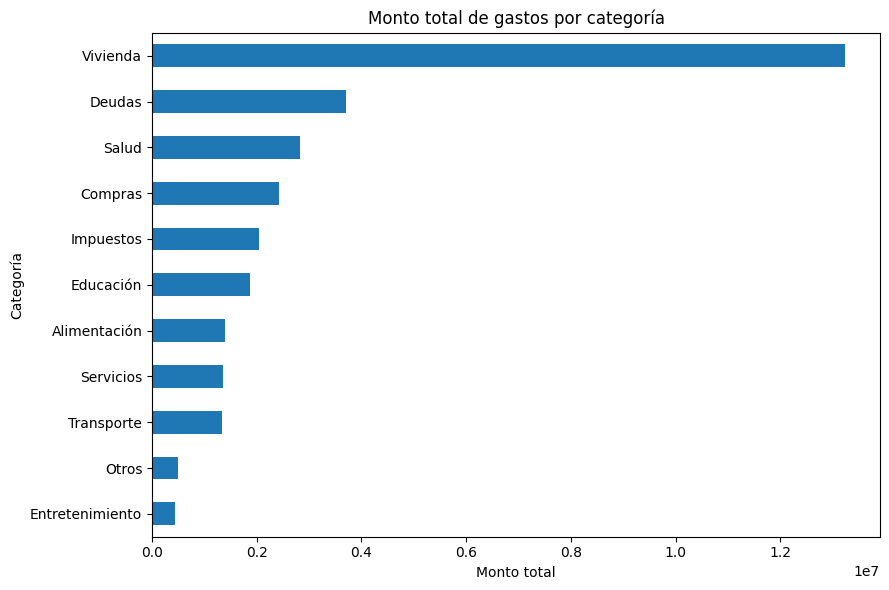

In [10]:
gastos = transacciones[
    transacciones["tipo"] == "GASTO"
]

resumen_gastos_categoria = (
    gastos.groupby("categoria")["monto"]
    .agg(["count", "sum", "mean", "median", "max"])
    .sort_values("sum", ascending=False)
)

display(resumen_gastos_categoria)

ax = resumen_gastos_categoria["sum"].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Monto total de gastos por categoría",
)

ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
plt.tight_layout()
plt.show()

**Interpretación:** El análisis del monto total por categoría permite identificar los principales destinos del gasto registrados en el conjunto de datos. Las estadísticas descriptivas (cantidad, suma, media, mediana y monto máximo) ofrecen una visión general del comportamiento de cada categoría y facilitan la comparación entre los distintos tipos de egresos.

### **8.2 <u>Medios de pago utilizados en gastos**</u>

In [11]:
display(
    gastos["medio_pago"]
    .value_counts()
    .rename("cantidad")
    .to_frame()
)

,cantidad
medio_pago,
Tarjeta de crédito,12296
Billetera digital,8077
Pago con QR,8069
Tarjeta de débito,7932
Efectivo,7911
Transferencia bancaria,7867
Débito automático,7848


**Interpretación:** La distribución de los medios de pago muestra los diferentes mecanismos utilizados para realizar las transacciones de gasto. La presencia de múltiples medios de pago aporta mayor diversidad al conjunto de datos y permite representar distintos hábitos de consumo en el análisis exploratorio.

### **8.3 <u>Ingresos por categoría**</u>

,count,sum,mean,median,max
categoria,,,,,
Salario,12000,"45,501,204.1400","3,791.7670","3,710.2250","7,152.0300"
Transferencia recibida,1001,"347,165.4800",346.8187,339.0800,697.3700
Venta,376,"291,834.4100",776.1553,540.9150,"6,171.0600"
Otros ingresos,349,"135,185.7400",387.3517,331.6600,"1,437.1800"
Reintegro,806,"89,983.9800",111.6427,111.7700,219.9600


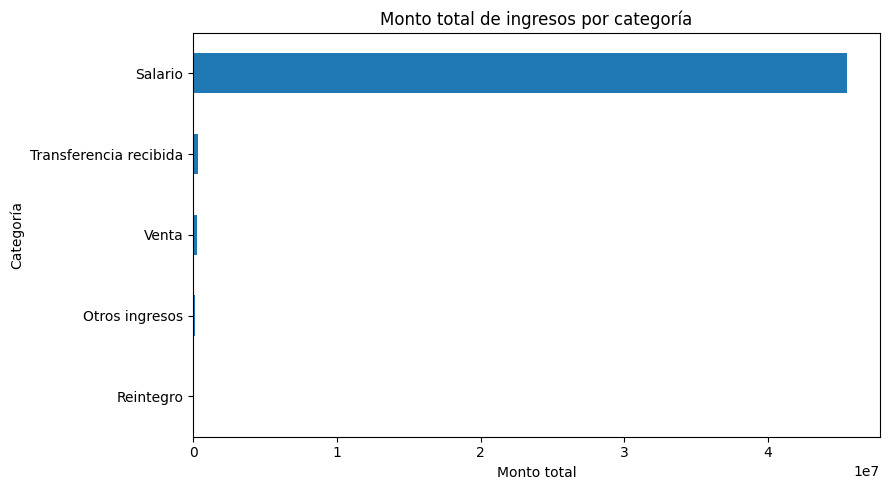

In [12]:
ingresos = transacciones[
    transacciones["tipo"] == "INGRESO"
]

resumen_ingresos_categoria = (
    ingresos.groupby("categoria")["monto"]
    .agg(["count", "sum", "mean", "median", "max"])
    .sort_values("sum", ascending=False)
)

display(resumen_ingresos_categoria)

ax = resumen_ingresos_categoria["sum"].sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    title="Monto total de ingresos por categoría",
)

ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
plt.tight_layout()
plt.show()

**Interpretación:** El análisis de los ingresos por categoría evidencia que la principal fuente de ingresos corresponde a los salarios, complementada por categorías como transferencias recibidas, reintegros y ventas. Esta distribución busca representar un escenario financiero sintético cercano al comportamiento esperado de un usuario promedio.

### **8.4 <u>Medios de acreditación de ingresos</u>**

In [13]:
display(
    ingresos["medio_pago"]
    .value_counts()
    .rename("cantidad")
    .to_frame()
)

,cantidad
medio_pago,
Acreditación automática,2945
Transferencia bancaria,2932
Efectivo,2931
Billetera digital,2919
Depósito en cuenta,2805


**Interpretación:** La distribución de los medios de acreditación presenta una utilización relativamente equilibrada entre los distintos canales disponibles para recibir ingresos. Esta configuración contribuye a representar diversas formas de acreditación y aporta mayor variedad al conjunto de datos sintético.

## **9. Relación entre variables financieras**

En esta sección se analiza la correlación lineal entre las principales variables financieras de los usuarios mediante una matriz de correlación. Este análisis permite identificar asociaciones positivas o negativas entre los indicadores económicos y comprender cómo se relacionan entre sí antes de la etapa de Ingeniería de Atributos y entrenamiento de modelos.

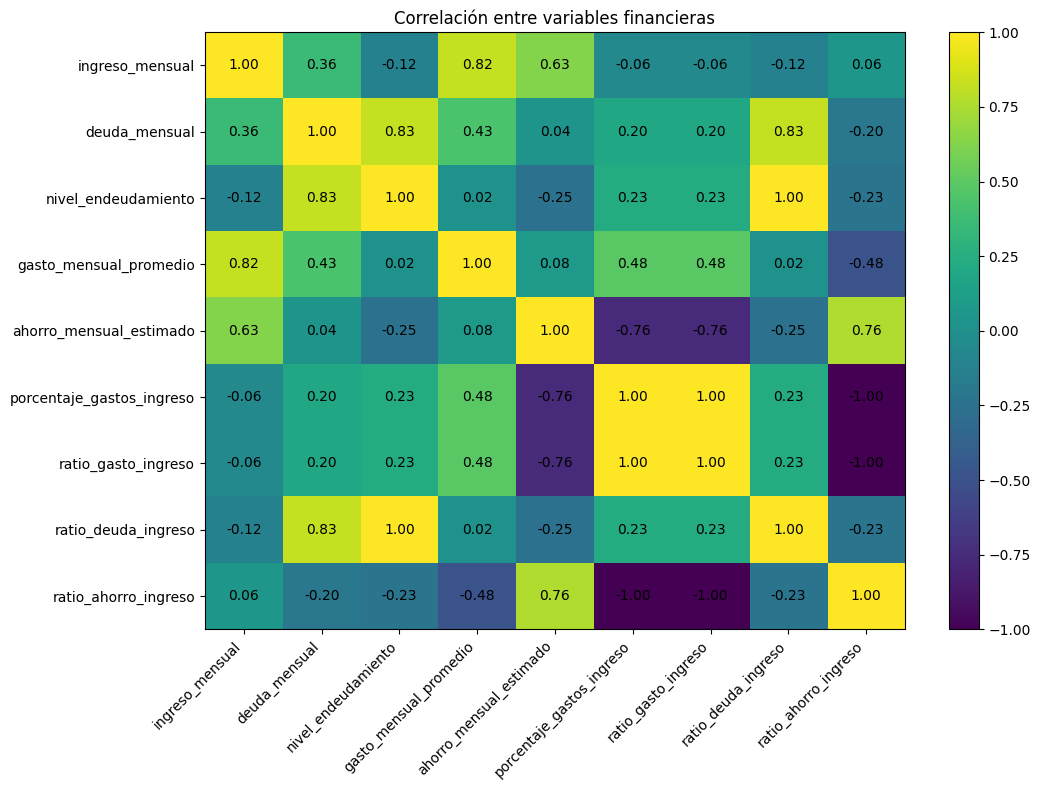

In [14]:
variables_correlacion = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
    "ratio_gasto_ingreso",
    "ratio_deuda_ingreso",
    "ratio_ahorro_ingreso",
]

correlaciones = usuarios[variables_correlacion].corr()

fig, ax = plt.subplots(figsize=(11, 8))
imagen = ax.imshow(correlaciones, aspect="auto")
ax.set_xticks(range(len(correlaciones.columns)))
ax.set_yticks(range(len(correlaciones.index)))
ax.set_xticklabels(correlaciones.columns, rotation=45, ha="right")
ax.set_yticklabels(correlaciones.index)

for fila in range(len(correlaciones.index)):
    for columna in range(len(correlaciones.columns)):
        ax.text(
            columna,
            fila,
            f"{correlaciones.iloc[fila, columna]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("Correlación entre variables financieras")
fig.colorbar(imagen, ax=ax)
plt.tight_layout()
plt.show()


**Interpretación:**

La matriz de correlación permite identificar el grado de asociación lineal entre las variables financieras del conjunto de datos. Se esperan relaciones consistentes entre ingresos, gastos, ahorro y endeudamiento, ya que varios indicadores se construyen a partir de estas magnitudes.

La presencia de correlaciones elevadas entre ratios y variables originales no implica necesariamente que todas deban incorporarse al modelo. El análisis sirve para detectar redundancias, comprender la estructura del dataset y justificar la selección posterior de atributos.


### **9.1 <u>Indicadores de equilibrio financiero</u>**

El equilibrio financiero mensual puede analizarse comparando los ingresos con los gastos y observando por separado el nivel de endeudamiento y la capacidad de ahorro.

En esta sección se resumen las variables centrales del usuario y se calcula un margen mensual estimado:

```text
margen_mensual_estimado = ingreso_mensual - gasto_mensual_promedio
```

Este indicador no representa el saldo de una cuenta bancaria. Es una medida analítica que ayuda a describir el margen disponible entre los ingresos y los gastos mensuales estimados.

El nivel de endeudamiento se analiza por separado como indicador de riesgo financiero y no se descuenta nuevamente del margen mensual, ya que los pagos de deuda forman parte de los gastos registrados.

,count,mean,std,min,25%,50%,75%,max
ingreso_mensual,"1,000.0000","3,863.7800","1,422.1400","1,246.5000","2,718.7900","3,779.6100","4,882.9300","7,006.0500"
gasto_mensual_promedio,"1,000.0000","2,593.1000","1,108.1500",576.3400,"1,713.1600","2,492.3000","3,293.4200","6,995.3400"
deuda_mensual,"1,000.0000",726.2500,551.0700,2.3500,334.4200,565.0800,964.9900,"3,059.1300"
ahorro_mensual_estimado,"1,000.0000","1,270.6800",807.5800,-124.1900,653.0900,"1,084.2400","1,721.3600","4,591.9900"
margen_mensual_estimado,"1,000.0000","1,270.6800",807.5800,-124.1900,653.0900,"1,084.2300","1,721.3600","4,591.9900"


,usuarios,ingreso_promedio,gasto_promedio,deuda_promedio,ahorro_promedio,margen_promedio
perfil_financiero,,,,,,
En observación,457,"3,713.3900","2,643.3200",650.2600,"1,070.0700","1,070.0700"
En riesgo,276,"3,859.1500","3,023.0900","1,185.4800",836.0600,836.0600
Saludable,267,"4,125.9700","2,062.6700",381.6100,"2,063.3100","2,063.3100"


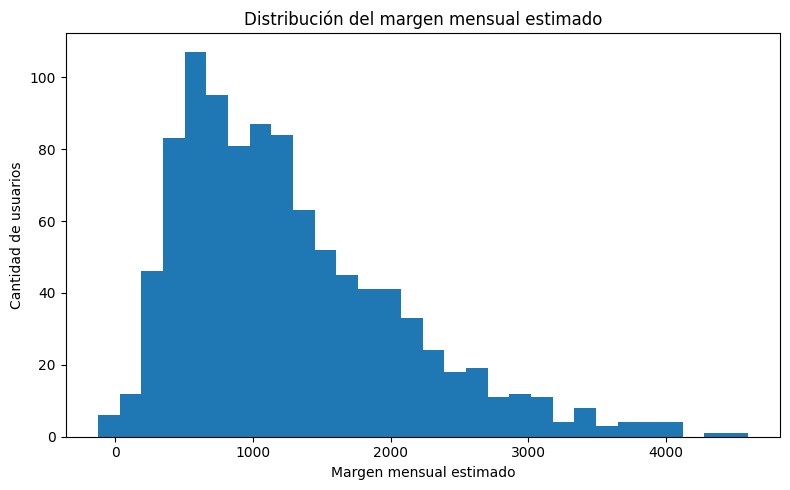

In [15]:

usuarios["margen_mensual_estimado"] = (
    usuarios["ingreso_mensual"]
    - usuarios["gasto_mensual_promedio"]
)

columnas_equilibrio = [
    "ingreso_mensual",
    "gasto_mensual_promedio",
    "deuda_mensual",
    "ahorro_mensual_estimado",
    "margen_mensual_estimado",
]

display(
    usuarios[columnas_equilibrio]
    .describe()
    .T
    .round(2)
)

equilibrio_por_perfil = (
    usuarios
    .groupby("perfil_financiero")
    .agg(
        usuarios=("usuario_id", "count"),
        ingreso_promedio=("ingreso_mensual", "mean"),
        gasto_promedio=("gasto_mensual_promedio", "mean"),
        deuda_promedio=("deuda_mensual", "mean"),
        ahorro_promedio=("ahorro_mensual_estimado", "mean"),
        margen_promedio=("margen_mensual_estimado", "mean"),
    )
    .round(2)
)

display(equilibrio_por_perfil)

ax = usuarios["margen_mensual_estimado"].plot(
    kind="hist",
    bins=30,
    figsize=(8, 5),
    title="Distribución del margen mensual estimado",
)

ax.set_xlabel("Margen mensual estimado")
ax.set_ylabel("Cantidad de usuarios")

plt.tight_layout()
plt.show()

## **10. Procesamiento financiero, textual e ingeniería de atributos**

En esta etapa se generan y preparan variables derivadas a partir de la información financiera y textual disponible. Se incorporan atributos temporales, monetarios, conductuales y textuales con el objetivo de enriquecer la representación de los datos.

Las variables creadas permiten:

- representar patrones temporales de las transacciones;
- normalizar descripciones para el clasificador textual;
- identificar recurrencia y transacciones de monto elevado;
- resumir el comportamiento financiero a nivel de usuario;
- construir ratios comparables entre personas con distintos niveles de ingreso.

La ingeniería de atributos se diseña de forma reproducible para que las mismas transformaciones puedan utilizarse posteriormente durante la inferencia.


In [16]:
def crear_features_transacciones(df: pd.DataFrame) -> pd.DataFrame:
    resultado = df.copy()

    # ==========================
    # Variables temporales
    # ==========================
    resultado["anio"] = resultado["fecha"].dt.year
    resultado["mes"] = resultado["fecha"].dt.month
    resultado["trimestre"] = resultado["fecha"].dt.quarter
    resultado["dia_semana"] = resultado["fecha"].dt.dayofweek
    resultado["es_fin_de_semana"] = (
        resultado["dia_semana"].isin([5, 6]).astype(int)
    )

    # ==========================
    # Variables monetarias
    # ==========================
    resultado["monto_log"] = np.log1p(resultado["monto"])

    mediana_monto_usuario = (
        resultado.groupby("usuario_id")["monto"]
        .transform("median")
    )

    resultado["es_transaccion_grande"] = (
        resultado["monto"] > (2 * mediana_monto_usuario)
    ).astype(int)

    # ==========================
    # Variables textuales
    # ==========================
    resultado["longitud_descripcion"] = (
        resultado["descripcion_limpia"].str.len()
    )

    resultado["cantidad_palabras"] = (
        resultado["descripcion_limpia"].str.split().str.len()
    )

    # ==========================
    # Variables binarias
    # ==========================
    resultado["recurrente_binario"] = (
        resultado["recurrente"]
        .str.lower()
        .map({"sí": 1, "si": 1, "no": 0})
        .fillna(0)
        .astype(int)
    )

    return resultado


transacciones_features = crear_features_transacciones(transacciones)

columnas_features_creadas = [
    "descripcion_limpia",
    "anio",
    "mes",
    "trimestre",
    "dia_semana",
    "es_fin_de_semana",
    "monto_log",
    "longitud_descripcion",
    "cantidad_palabras",
    "recurrente_binario",
    "es_transaccion_grande",
]

display(transacciones_features[columnas_features_creadas].head())

,descripcion_limpia,anio,mes,trimestre,dia_semana,es_fin_de_semana,monto_log,longitud_descripcion,cantidad_palabras,recurrente_binario,es_transaccion_grande
0,renta mensual,2026,5,2,1,0,6.6613,13,2,1,1
1,abono de television local,2025,11,4,6,1,4.2601,25,4,0,0
2,remuneracion,2026,2,1,0,0,8.6295,12,1,1,1
3,deposito de haberes,2025,12,4,0,0,7.8805,19,3,1,1
4,operacion reintegro,2025,9,3,1,0,4.7513,19,2,0,0


**Interpretación:** Se incorporaron nuevas variables derivadas que amplían la información disponible en el conjunto de datos. Entre ellas se incluyen atributos temporales (año, mes, trimestre, día de la semana y fin de semana), transformaciones monetarias (monto en escala logarítmica), características textuales (longitud de la descripción y cantidad de palabras) e indicadores binarios, como la recurrencia de la transacción y la identificación de operaciones de monto significativamente superior a la mediana del usuario. Estas variables constituyen la base para las etapas posteriores de modelado y análisis predictivo.

## **11. Variables agregadas por usuario**

En esta sección se consolidan las transacciones a nivel de usuario mediante la generación de variables agregadas. Se calculan métricas descriptivas sobre la actividad financiera, como la cantidad de transacciones, estadísticas de los montos y características relacionadas con la recurrencia y diversidad de categorías. Además, se incorporan indicadores financieros derivados que representan la relación entre ingresos, gastos, deuda y ahorro, los cuales servirán como variables de entrada para los modelos de Machine Learning.

In [17]:
# Solo las transacciones de tipo INGRESO y GASTO forman parte del análisis financiero.
transacciones_financieras = transacciones_features[
    transacciones_features["tipo"].isin(["INGRESO", "GASTO"])
].copy()

resumen_transacciones_usuario = (
    transacciones_financieras
    .groupby("usuario_id")
    .agg(
        cantidad_transacciones=("transaction_id", "count"),
        monto_total=("monto", "sum"),
        monto_promedio_transaccion=("monto", "mean"),
        monto_mediano=("monto", "median"),
        monto_maximo=("monto", "max"),
        desviacion_montos=("monto", "std"),
        cantidad_recurrentes=("recurrente_binario", "sum"),
        cantidad_transacciones_grandes=("es_transaccion_grande", "sum"),
        categorias_distintas=("categoria", "nunique"),
    )
    .reset_index()
)

dataset_perfiles = usuarios.merge(
    resumen_transacciones_usuario,
    on="usuario_id",
    how="left",
    validate="one_to_one",
)

dataset_perfiles["ratio_deuda_ingreso_calculado"] = np.where(
    dataset_perfiles["ingreso_mensual"] > 0,
    dataset_perfiles["deuda_mensual"] / dataset_perfiles["ingreso_mensual"],
    0,
)

dataset_perfiles["ratio_gasto_ingreso_calculado"] = np.where(
    dataset_perfiles["ingreso_mensual"] > 0,
    dataset_perfiles["gasto_mensual_promedio"]
    / dataset_perfiles["ingreso_mensual"],
    0,
)

dataset_perfiles["ratio_ahorro_ingreso_calculado"] = np.where(
    dataset_perfiles["ingreso_mensual"] > 0,
    dataset_perfiles["ahorro_mensual_estimado"]
    / dataset_perfiles["ingreso_mensual"],
    0,
)

display(dataset_perfiles.head())


,usuario_id,ingreso_mensual,gasto_mensual_promedio,deuda_mensual,ahorro_mensual_estimado,porcentaje_gastos_ingreso,nivel_endeudamiento,porcentaje_ahorro_ingreso,frecuencia_ahorro,perfil_financiero,estado,ratio_gasto_ingreso,ratio_deuda_ingreso,ratio_ahorro_ingreso,margen_mensual_estimado,cantidad_transacciones,monto_total,monto_promedio_transaccion,monto_mediano,monto_maximo,desviacion_montos,cantidad_recurrentes,cantidad_transacciones_grandes,categorias_distintas,ratio_deuda_ingreso_calculado,ratio_gasto_ingreso_calculado,ratio_ahorro_ingreso_calculado
0,USR0001,"3,229.8700","2,790.9400",548.3600,438.9300,86.4100,16.9800,13.5900,Media,En riesgo,ACTIVO,0.8641,0.1698,0.1359,438.9300,72,"72,249.7000","1,003.4681",320.5050,"4,604.1800","1,225.0567",29,31,12,0.1698,0.8641,0.1359
1,USR0002,"1,612.9500","1,095.2000",250.7700,517.7500,67.9000,15.5500,32.1000,Alta,En observación,ACTIVO,0.6790,0.1555,0.3210,517.7500,73,"32,497.8200",445.1756,193.9800,"1,636.7200",557.5787,25,22,13,0.1555,0.6790,0.3210
2,USR0003,"2,075.6400","1,979.8900",452.1500,95.7400,95.3900,21.7800,4.6100,Baja,En riesgo,ACTIVO,0.9539,0.2178,0.0461,95.7500,74,"48,666.3300",657.6531,420.9300,"2,122.4200",713.9468,25,22,13,0.2178,0.9539,0.0461
3,USR0004,"2,773.6200","1,453.7600","1,368.2300","1,319.8600",52.4100,49.3300,47.5900,Alta,En riesgo,ACTIVO,0.5241,0.4933,0.4759,"1,319.8600",74,"50,728.5900",685.5215,150.0150,"3,591.2100","1,000.1633",23,29,13,0.4933,0.5241,0.4759
4,USR0005,"3,372.7100","2,630.7300",532.9800,741.9900,78.0000,15.8000,22.0000,Alta,En observación,ACTIVO,0.7800,0.1580,0.2200,741.9800,75,"72,041.3000",960.5507,358.9500,"3,423.0800","1,152.5458",30,29,13,0.1580,0.7800,0.2200


**Interpretación:** Se construyó un conjunto consolidado a nivel de usuario que combina la información financiera original con variables agregadas obtenidas a partir del historial de transacciones.

Este dataset representa el comportamiento de cada usuario mediante cantidades, montos, recurrencia, diversidad de categorías y ratios financieros. La consolidación facilita el entrenamiento del clasificador de perfil y mantiene una separación clara entre los datos transaccionales y los indicadores personales.


## **12. Exportación de datasets procesados**

Una vez finalizado el proceso de limpieza, transformación e ingeniería de atributos, se exportan dos conjuntos de datos:

- `transacciones_features.csv`: transacciones enriquecidas con atributos temporales, monetarios y textuales.
- `usuarios_features.csv`: información consolidada a nivel de usuario para el análisis y la clasificación del perfil financiero.

Estos archivos permiten reutilizar los resultados del procesamiento sin repetir todas las etapas anteriores y facilitan la integración con el AI-Service.


In [18]:
RUTA_TRANSACCIONES_PROCESADAS = (
    PROCESSED_DIR / "transacciones_features.csv"
)
RUTA_PERFILES_PROCESADOS = (
    PROCESSED_DIR / "usuarios_features.csv"
)

transacciones_features.to_csv(
    RUTA_TRANSACCIONES_PROCESADAS,
    index=False,
)
dataset_perfiles.to_csv(
    RUTA_PERFILES_PROCESADOS,
    index=False,
)

print(RUTA_TRANSACCIONES_PROCESADAS)
print(RUTA_PERFILES_PROCESADOS)

artefactos_financeai_v10/datos_procesados/transacciones_features.csv
artefactos_financeai_v10/datos_procesados/usuarios_features.csv


**Resultado:** Los conjuntos de datos procesados fueron exportados correctamente al directorio correspondiente. Estos archivos constituyen la entrada para las etapas de clasificación de transacciones, análisis del perfil financiero y entrenamiento de los modelos de Machine Learning, permitiendo reutilizar la información procesada sin necesidad de repetir las etapas previas del pipeline.

## **13. Modelo de clasificación de transacciones**

Se entrena un único clasificador para categorías de **gastos e ingresos**.

La categoría se determina principalmente por el significado de la descripción. El pipeline combina TF-IDF de palabras y TF-IDF de caracteres. Esto permite reconocer expresiones completas y tolerar variaciones como `nómina`, `nomina`, `pago de nómina` o `pago nomina`.

El monto, la fecha, el medio de pago y la recurrencia no se utilizan para decidir la categoría, porque pueden introducir asociaciones artificiales.


In [19]:
# Se utilizan todas las transacciones: gastos e ingresos.
# ENTRENAMIENTO DEL CLASIFICADOR DE CATEGORÍAS
# CON EJEMPLOS DE MARCAS COMERCIALES

def normalizar_descripcion_marca(texto: str) -> str:
    if pd.isna(texto):
        return ""

    texto = str(texto).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto,
    )

    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )

    texto = re.sub(
        r"[^a-z0-9\s]",
        " ",
        texto,
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto,
    )

    return texto.strip()


ejemplos_marcas = pd.DataFrame([
    # Entretenimiento y streaming
    {"descripcion": "Netflix", "categoria": "Entretenimiento"},
    {"descripcion": "Pago Netflix", "categoria": "Entretenimiento"},
    {"descripcion": "Netflix Premium", "categoria": "Entretenimiento"},
    {"descripcion": "Suscripción Netflix", "categoria": "Entretenimiento"},

    {"descripcion": "Spotify", "categoria": "Entretenimiento"},
    {"descripcion": "Pago Spotify", "categoria": "Entretenimiento"},
    {"descripcion": "Spotify Premium", "categoria": "Entretenimiento"},
    {"descripcion": "Suscripción Spotify", "categoria": "Entretenimiento"},

    {"descripcion": "Disney Plus", "categoria": "Entretenimiento"},
    {"descripcion": "Pago Disney Plus", "categoria": "Entretenimiento"},
    {"descripcion": "Suscripción Disney Plus", "categoria": "Entretenimiento"},

    {"descripcion": "Prime Video", "categoria": "Entretenimiento"},
    {"descripcion": "Pago Prime Video", "categoria": "Entretenimiento"},

    {"descripcion": "HBO Max", "categoria": "Entretenimiento"},
    {"descripcion": "Pago HBO Max", "categoria": "Entretenimiento"},

    {"descripcion": "Steam", "categoria": "Entretenimiento"},
    {"descripcion": "Compra en Steam", "categoria": "Entretenimiento"},
    {"descripcion": "Videojuego en Steam", "categoria": "Entretenimiento"},

    {"descripcion": "Epic Games", "categoria": "Entretenimiento"},
    {"descripcion": "Compra en Epic Games", "categoria": "Entretenimiento"},

    # Transporte
    {"descripcion": "Uber", "categoria": "Transporte"},
    {"descripcion": "Viaje en Uber", "categoria": "Transporte"},
    {"descripcion": "Pago Uber", "categoria": "Transporte"},

    {"descripcion": "Cabify", "categoria": "Transporte"},
    {"descripcion": "Viaje en Cabify", "categoria": "Transporte"},
    {"descripcion": "Pago Cabify", "categoria": "Transporte"},

    {"descripcion": "DiDi", "categoria": "Transporte"},
    {"descripcion": "Viaje en DiDi", "categoria": "Transporte"},
    {"descripcion": "Pago DiDi", "categoria": "Transporte"},

    # Compras
    {"descripcion": "Mercado Libre", "categoria": "Compras"},
    {"descripcion": "Compra en Mercado Libre", "categoria": "Compras"},
    {"descripcion": "Pago Mercado Libre", "categoria": "Compras"},

    {"descripcion": "Amazon", "categoria": "Compras"},
    {"descripcion": "Compra en Amazon", "categoria": "Compras"},
    {"descripcion": "Pago Amazon", "categoria": "Compras"},

    {"descripcion": "Temu", "categoria": "Compras"},
    {"descripcion": "Compra en Temu", "categoria": "Compras"},

    {"descripcion": "Shein", "categoria": "Compras"},
    {"descripcion": "Compra en Shein", "categoria": "Compras"},

    # Alimentación y delivery
    {"descripcion": "PedidosYa", "categoria": "Alimentación"},
    {"descripcion": "Pedido en PedidosYa", "categoria": "Alimentación"},
    {"descripcion": "Pago PedidosYa", "categoria": "Alimentación"},

    {"descripcion": "Rappi", "categoria": "Alimentación"},
    {"descripcion": "Pedido en Rappi", "categoria": "Alimentación"},
    {"descripcion": "Pago Rappi", "categoria": "Alimentación"},

    {"descripcion": "McDonalds", "categoria": "Alimentación"},
    {"descripcion": "Compra en McDonalds", "categoria": "Alimentación"},

    {"descripcion": "Burger King", "categoria": "Alimentación"},
    {"descripcion": "Compra en Burger King", "categoria": "Alimentación"},

    {"descripcion": "KFC", "categoria": "Alimentación"},
    {"descripcion": "Compra en KFC", "categoria": "Alimentación"},
])


ejemplos_marcas["descripcion_limpia"] = (
    ejemplos_marcas["descripcion"]
    .apply(normalizar_descripcion_marca)
)


ejemplos_marcas_modelo = ejemplos_marcas[
    [
        "descripcion_limpia",
        "categoria",
    ]
].copy()


transacciones_modelo = transacciones_features.copy()


transacciones_modelo = pd.concat(
    [
        transacciones_modelo,
        ejemplos_marcas_modelo,
    ],
    ignore_index=True,
)


features_categoria = [
    "descripcion_limpia",
]

target_categoria = "categoria"

X_categoria = (
    transacciones_modelo[features_categoria]
    .copy()
)

y_categoria = (
    transacciones_modelo[target_categoria]
    .astype(str)
    .str.strip()
    .copy()
)


preprocesador_categoria = ColumnTransformer(
    transformers=[
        (
            "texto_palabras",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=12000,
                sublinear_tf=True,
                strip_accents="unicode",
            ),
            "descripcion_limpia",
        ),
        (
            "texto_caracteres",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2,
                max_features=18000,
                sublinear_tf=True,
                strip_accents="unicode",
            ),
            "descripcion_limpia",
        ),
    ],
    remainder="drop",
)


# Pipeline base. Los parámetros definitivos se eligen mediante
# GridSearchCV en una celda posterior.
modelo_categoria_base = Pipeline([
    (
        "preprocesamiento",
        preprocesador_categoria,
    ),
    (
        "clasificador",
        SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            max_iter=2000,
            tol=1e-3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            early_stopping=False,
        ),
    ),
])

# Se asigna inicialmente para conservar compatibilidad con las
# celdas posteriores. Luego será reemplazado por best_estimator_.
modelo_categoria = modelo_categoria_base


print(
    f"Ejemplos comerciales agregados: "
    f"{len(ejemplos_marcas_modelo)}"
)

print(
    f"Cantidad total de transacciones utilizadas: "
    f"{len(X_categoria)}"
)

print(
    f"Cantidad de categorías: "
    f"{y_categoria.nunique()}"
)

display(
    y_categoria
    .value_counts()
    .rename("cantidad")
    .to_frame()
)

display(
    ejemplos_marcas_modelo.head(15)
)


Ejemplos comerciales agregados: 51
Cantidad total de transacciones utilizadas: 74583
Cantidad de categorías: 16


,cantidad
categoria,
Vivienda,12547
Alimentación,12272
Salario,12000
Servicios,6135
Transporte,5902
Salud,5391
Entretenimiento,4144
Compras,3621
Educación,3557


,descripcion_limpia,categoria
0,netflix,Entretenimiento
1,pago netflix,Entretenimiento
2,netflix premium,Entretenimiento
3,suscripcion netflix,Entretenimiento
4,spotify,Entretenimiento
5,pago spotify,Entretenimiento
6,spotify premium,Entretenimiento
7,suscripcion spotify,Entretenimiento
8,disney plus,Entretenimiento
9,pago disney plus,Entretenimiento


**Interpretación:** El clasificador utiliza el contenido semántico de la descripción. Los n-gramas de palabras reconocen términos y frases, mientras que los n-gramas de caracteres aportan tolerancia frente a tildes omitidas y variaciones menores. Las otras variables siguen disponibles para el análisis financiero, pero no modifican la categoría predicha.


## **14. Evaluación mediante hold-out estratificado**

Como primera evaluación, el conjunto de datos se divide en entrenamiento y prueba mediante un esquema hold-out estratificado. Esta estrategia conserva la proporción de las distintas categorías de gasto en ambos subconjuntos, permitiendo estimar el desempeño del modelo sobre transacciones con una distribución similar a la observada durante el entrenamiento.

Se reportan las métricas de Accuracy, F1 Macro y F1 Weighted, junto con el informe de clasificación y la matriz de confusión para analizar el comportamiento del modelo en cada categoría.

In [20]:
# ============================================================
# Hold-out estratificado
# ============================================================

X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_categoria,
    y_categoria,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_categoria,
)

print("Train:", len(X_cat_train))
print("Test:", len(X_cat_test))
print("Categorías:", y_cat_train.nunique())


# ============================================================
# Tuning de hiperparámetros con validación agrupada
# ============================================================
# Dentro del conjunto de entrenamiento, una misma descripción
# permanece en un único fold. Esto reduce el riesgo de premiar
# al modelo por memorizar exactamente la misma frase.

grupos_tuning = X_cat_train[
    "descripcion_limpia"
].copy()

cv_tuning = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

param_grid_categoria = {
    "preprocesamiento__texto_palabras__max_features": [
        10000,
        14000,
    ],
    "preprocesamiento__texto_caracteres__max_features": [
        16000,
        22000,
    ],
    "clasificador__alpha": [
        1e-6,
        1e-5,
        1e-4,
    ],
}

busqueda_categoria = GridSearchCV(
    estimator=modelo_categoria_base,
    param_grid=param_grid_categoria,
    scoring="f1_macro",
    cv=cv_tuning,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
)

busqueda_categoria.fit(
    X_cat_train,
    y_cat_train,
    groups=grupos_tuning,
)

modelo_categoria = busqueda_categoria.best_estimator_

print("\n✅ Tuning finalizado")
print("Mejor F1 macro CV:", round(busqueda_categoria.best_score_, 4))
print("Mejores parámetros:")
display(pd.Series(busqueda_categoria.best_params_))


# ============================================================
# Evaluación hold-out del mejor pipeline
# ============================================================

pred_categoria_train = modelo_categoria.predict(
    X_cat_train
)

pred_categoria = modelo_categoria.predict(
    X_cat_test
)

accuracy_categoria_train = accuracy_score(
    y_cat_train,
    pred_categoria_train,
)

metricas_categoria_holdout = {
    "accuracy": accuracy_score(
        y_cat_test,
        pred_categoria,
    ),
    "precision_macro": precision_score(
        y_cat_test,
        pred_categoria,
        average="macro",
        zero_division=0,
    ),
    "recall_macro": recall_score(
        y_cat_test,
        pred_categoria,
        average="macro",
        zero_division=0,
    ),
    "f1_macro": f1_score(
        y_cat_test,
        pred_categoria,
        average="macro",
        zero_division=0,
    ),
    "f1_weighted": f1_score(
        y_cat_test,
        pred_categoria,
        average="weighted",
        zero_division=0,
    ),
}

metricas_categoria_overfitting = {
    "accuracy_train": accuracy_categoria_train,
    "accuracy_test": metricas_categoria_holdout["accuracy"],
    "brecha_train_test": (
        accuracy_categoria_train
        - metricas_categoria_holdout["accuracy"]
    ),
    "f1_macro_train": f1_score(
        y_cat_train,
        pred_categoria_train,
        average="macro",
        zero_division=0,
    ),
    "f1_macro_test": metricas_categoria_holdout["f1_macro"],
}

display(
    pd.Series(
        metricas_categoria_holdout,
        name="clasificacion_categorias_holdout",
    ).round(4)
)

display(
    pd.Series(
        metricas_categoria_overfitting,
        name="diagnostico_overfitting_categorias",
    ).round(4)
)

brecha_categoria = metricas_categoria_overfitting[
    "brecha_train_test"
]

if brecha_categoria <= 0.03:
    print("✅ No se observa overfitting significativo.")
elif brecha_categoria <= 0.05:
    print("⚠️ Brecha train/test moderada pero aceptable.")
else:
    print("🚨 Revisar posible overfitting.")

print(
    classification_report(
        y_cat_test,
        pred_categoria,
        zero_division=0,
    )
)


Train: 59666
Test: 14917
Categorías: 16
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Tuning finalizado
Mejor F1 macro CV: 0.9766
Mejores parámetros:


,0
clasificador__alpha,0.0000
preprocesamiento__texto_caracteres__max_features,"16,000.0000"
preprocesamiento__texto_palabras__max_features,"10,000.0000"


,clasificacion_categorias_holdout
accuracy,1.0000
precision_macro,1.0000
recall_macro,1.0000
f1_macro,1.0000
f1_weighted,1.0000


,diagnostico_overfitting_categorias
accuracy_train,1.0000
accuracy_test,1.0000
brecha_train_test,0.0000
f1_macro_train,1.0000
f1_macro_test,1.0000


✅ No se observa overfitting significativo.
                        precision    recall  f1-score   support

          Alimentación       1.00      1.00      1.00      2455
               Compras       1.00      1.00      1.00       724
                Deudas       1.00      1.00      1.00       600
             Educación       1.00      1.00      1.00       711
       Entretenimiento       1.00      1.00      1.00       829
             Impuestos       1.00      1.00      1.00       415
                 Otros       1.00      1.00      1.00       282
        Otros ingresos       1.00      1.00      1.00        70
             Reintegro       1.00      1.00      1.00       161
               Salario       1.00      1.00      1.00      2400
                 Salud       1.00      1.00      1.00      1078
             Servicios       1.00      1.00      1.00      1227
Transferencia recibida       1.00      1.00      1.00       200
            Transporte       1.00      1.00      1.00      1

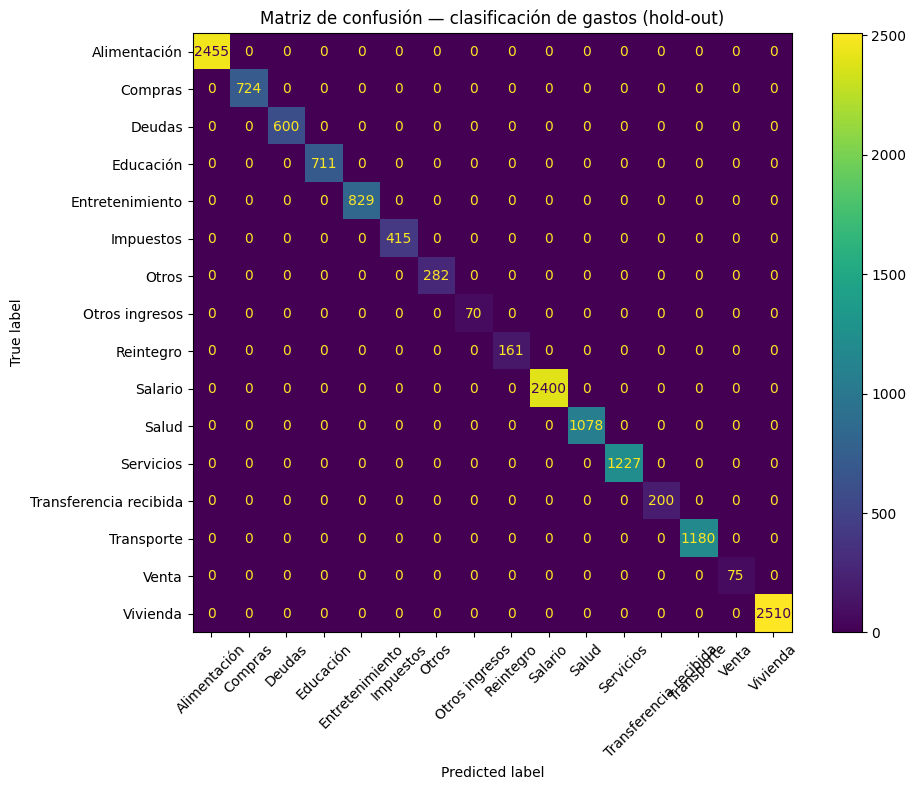

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_cat_test,
    pred_categoria,
    xticks_rotation=45,
    ax=ax,
)
ax.set_title(
    "Matriz de confusión — clasificación de gastos (hold-out)"
)
plt.tight_layout()
plt.show()

### **14.1 <u>Calibración de probabilidades y control de confianza</u>**

Además de acertar la categoría, FinSightAI necesita que la probabilidad reportada sea útil como **confianza**. Por eso se compara el mejor pipeline optimizado con una versión calibrada mediante `CalibratedClassifierCV`.

La calibración no busca inflar porcentajes: busca que una confianza alta corresponda realmente a predicciones más fiables. Se usa `log_loss` como criterio adicional porque penaliza probabilidades excesivamente seguras cuando la predicción es incorrecta.

El modelo calibrado solo se selecciona para producción si mantiene un rendimiento de clasificación comparable al modelo base y no empeora de forma relevante el `log_loss`.


In [22]:
# ============================================================
# Calibración de probabilidades
# ============================================================

modelo_categoria_calibrado = CalibratedClassifierCV(
    estimator=modelo_categoria,
    method="sigmoid",
    cv=3,
    n_jobs=-1,
)

modelo_categoria_calibrado.fit(
    X_cat_train,
    y_cat_train,
)

pred_base = modelo_categoria.predict(
    X_cat_test
)

proba_base = modelo_categoria.predict_proba(
    X_cat_test
)

pred_calibrado = modelo_categoria_calibrado.predict(
    X_cat_test
)

proba_calibrado = modelo_categoria_calibrado.predict_proba(
    X_cat_test
)

f1_base = f1_score(
    y_cat_test,
    pred_base,
    average="macro",
    zero_division=0,
)

f1_calibrado = f1_score(
    y_cat_test,
    pred_calibrado,
    average="macro",
    zero_division=0,
)

accuracy_base = accuracy_score(
    y_cat_test,
    pred_base,
)

accuracy_calibrado = accuracy_score(
    y_cat_test,
    pred_calibrado,
)

logloss_base = log_loss(
    y_cat_test,
    proba_base,
    labels=modelo_categoria.classes_,
)

logloss_calibrado = log_loss(
    y_cat_test,
    proba_calibrado,
    labels=modelo_categoria_calibrado.classes_,
)

comparacion_calibracion = pd.DataFrame([
    {
        "modelo": "Pipeline optimizado",
        "accuracy": accuracy_base,
        "f1_macro": f1_base,
        "log_loss": logloss_base,
    },
    {
        "modelo": "Pipeline calibrado",
        "accuracy": accuracy_calibrado,
        "f1_macro": f1_calibrado,
        "log_loss": logloss_calibrado,
    },
])

display(
    comparacion_calibracion.round(4)
)

# ============================================================
# Selección automática del modelo de producción
# ============================================================
# Permitimos como máximo una caída mínima de F1 para obtener
# probabilidades mejor calibradas.

TOLERANCIA_F1_CALIBRACION = 0.01

calibrado_mantiene_f1 = (
    f1_calibrado
    >= f1_base - TOLERANCIA_F1_CALIBRACION
)

calibrado_mejora_logloss = (
    logloss_calibrado
    <= logloss_base
)

if (
    calibrado_mantiene_f1
    and calibrado_mejora_logloss
):
    modelo_categoria_produccion = (
        modelo_categoria_calibrado
    )
    nombre_modelo_categoria_produccion = (
        "SGDClassifier calibrado"
    )
    print(
        "✅ Se selecciona el modelo calibrado para producción."
    )
else:
    modelo_categoria_produccion = (
        modelo_categoria
    )
    nombre_modelo_categoria_produccion = (
        "SGDClassifier optimizado"
    )
    print(
        "ℹ️ Se conserva el pipeline optimizado sin calibración."
    )

print(
    "Modelo de producción:",
    nombre_modelo_categoria_produccion,
)


,modelo,accuracy,f1_macro,log_loss
0,Pipeline optimizado,1.0000,1.0000,0.0034
1,Pipeline calibrado,1.0000,1.0000,0.0012


✅ Se selecciona el modelo calibrado para producción.
Modelo de producción: SGDClassifier calibrado


### **Criterios ⭐⭐⭐⭐⭐ de aceptación**

Para considerar apto el clasificador se controlan cuatro aspectos: desempeño global, balance entre clases, sobreajuste y calidad de la confianza. Una entrada ambigua puede legítimamente tener confianza baja; el objetivo no es convertir todos los casos en 99%, sino obtener alta confianza cuando existe evidencia suficiente y reconocer la incertidumbre cuando no la hay.


In [23]:
# ============================================================
# Gate de calidad del modelo
# ============================================================

reporte_clases = classification_report(
    y_cat_test,
    pred_categoria,
    output_dict=True,
    zero_division=0,
)

f1_por_clase = {
    clase: metricas["f1-score"]
    for clase, metricas in reporte_clases.items()
    if isinstance(metricas, dict)
    and "f1-score" in metricas
    and clase not in {
        "macro avg",
        "weighted avg",
    }
}

f1_minimo_clase = (
    min(f1_por_clase.values())
    if f1_por_clase
    else 0.0
)

criterios_calidad = {
    "accuracy >= 0.90": (
        metricas_categoria_holdout["accuracy"]
        >= 0.90
    ),
    "f1_macro >= 0.88": (
        metricas_categoria_holdout["f1_macro"]
        >= 0.88
    ),
    "brecha_train_test <= 0.05": (
        abs(brecha_categoria)
        <= 0.05
    ),
    "f1_minimo_por_clase >= 0.80": (
        f1_minimo_clase
        >= 0.80
    ),
}

tabla_criterios = pd.DataFrame([
    {
        "criterio": criterio,
        "cumple": "✅" if cumple else "❌",
    }
    for criterio, cumple
    in criterios_calidad.items()
])

display(tabla_criterios)

print(
    "F1 mínimo entre categorías:",
    round(f1_minimo_clase, 4),
)

modelo_categoria_aprobado = all(
    criterios_calidad.values()
)

if modelo_categoria_aprobado:
    print(
        "⭐⭐⭐⭐⭐ MODELO APROBADO PARA PRODUCCIÓN"
    )
else:
    print(
        "⚠️ El modelo funciona, pero no cumple todavía "
        "todos los criterios 5 estrellas."
    )


,criterio,cumple
0,accuracy >= 0.90,✅
1,f1_macro >= 0.88,✅
2,brecha_train_test <= 0.05,✅
3,f1_minimo_por_clase >= 0.80,✅


F1 mínimo entre categorías: 1.0
⭐⭐⭐⭐⭐ MODELO APROBADO PARA PRODUCCIÓN


### ***Interpretación del resultado perfecto***
La evaluación mediante una partición aleatoria puede producir métricas muy elevadas, e incluso cercanas al rendimiento perfecto, debido a que el dataset sintético utiliza un vocabulario controlado. En este escenario, una misma descripción puede aparecer tanto en el conjunto de entrenamiento como en el de prueba, manteniendo una asociación prácticamente unívoca con su categoría correspondiente.

En consecuencia, esta evaluación verifica que el pipeline clasifique correctamente nuevas transacciones pertenecientes a descripciones ya conocidas. Sin embargo, por sí sola no permite medir la capacidad de generalización del modelo frente a descripciones no observadas durante el entrenamiento. Por este motivo, en la siguiente sección se aplica una validación agrupada por descripción, que constituye un escenario de evaluación más exigente y representativo.

## **15. Evaluación robusta agrupada por descripción**

Como segunda estrategia de evaluación, se aplica una validación cruzada utilizando **StratifiedGroupKFold**, donde cada descripción de transacción pertenece exclusivamente al conjunto de entrenamiento o al de validación.

A diferencia de la partición hold-out tradicional, este enfoque garantiza que una misma descripción textual no aparezca simultáneamente en ambos conjuntos, evitando que el modelo memorice expresiones específicas presentes en el dataset.

Esta metodología permite evaluar la capacidad de generalización del clasificador frente a descripciones no observadas durante el entrenamiento, representando un escenario más cercano al uso en producción. Por este motivo, las métricas obtenidas mediante esta estrategia suelen ser más exigentes que las alcanzadas con la partición hold-out tradicional.

Se reportan las métricas promedio obtenidas en los distintos pliegues, junto con el informe de clasificación y la matriz de confusión de uno de ellos.

In [24]:
# Cada descripción funciona como grupo de validación.
grupos_descripcion = X_categoria["descripcion_limpia"].copy()

cv_agrupada = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados_cv_categoria = cross_validate(
    estimator=modelo_categoria,
    X=X_categoria,
    y=y_categoria,
    groups=grupos_descripcion,
    cv=cv_agrupada,
    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
    },
    return_train_score=False,
    n_jobs=None,
)

metricas_cv_categoria = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
]

resumen_cv_categoria = pd.DataFrame({
    "metrica": metricas_cv_categoria,
    "promedio": [
        resultados_cv_categoria[f"test_{metrica}"].mean()
        for metrica in metricas_cv_categoria
    ],
    "desvio_estandar": [
        resultados_cv_categoria[f"test_{metrica}"].std()
        for metrica in metricas_cv_categoria
    ],
})

display(resumen_cv_categoria.round(4))

,metrica,promedio,desvio_estandar
0,accuracy,0.9967,0.0018
1,precision_macro,0.9858,0.0175
2,recall_macro,0.9771,0.0059
3,f1_macro,0.9767,0.0169
4,f1_weighted,0.9968,0.0019


In [25]:
indices_train_group, indices_test_group = next(
    cv_agrupada.split(
        X=X_categoria,
        y=y_categoria,
        groups=grupos_descripcion,
    )
)

X_cat_group_train = X_categoria.iloc[
    indices_train_group
].copy()

X_cat_group_test = X_categoria.iloc[
    indices_test_group
].copy()

y_cat_group_train = y_categoria.iloc[
    indices_train_group
].copy()

y_cat_group_test = y_categoria.iloc[
    indices_test_group
].copy()

# Se reutiliza exactamente la mejor configuración
# encontrada durante el tuning.
modelo_categoria_agrupado = (
    busqueda_categoria.best_estimator_
)


modelo_categoria_agrupado.fit(
    X_cat_group_train,
    y_cat_group_train,
)

pred_categoria_agrupada_train = (
    modelo_categoria_agrupado.predict(
        X_cat_group_train
    )
)

pred_categoria_agrupada = (
    modelo_categoria_agrupado.predict(
        X_cat_group_test
    )
)

descripciones_train = set(
    X_cat_group_train["descripcion_limpia"]
)

descripciones_test = set(
    X_cat_group_test["descripcion_limpia"]
)

descripciones_compartidas = (
    descripciones_train
    & descripciones_test
)

print(
    "Cantidad de transacciones de entrenamiento:",
    len(X_cat_group_train),
)
print(
    "Cantidad de transacciones de prueba:",
    len(X_cat_group_test),
)
print(
    "Descripciones únicas en entrenamiento:",
    len(descripciones_train),
)
print(
    "Descripciones únicas en prueba:",
    len(descripciones_test),
)
print(
    "Descripciones compartidas entre entrenamiento y prueba:",
    len(descripciones_compartidas),
)

accuracy_categoria_agrupada_train = accuracy_score(
    y_cat_group_train,
    pred_categoria_agrupada_train,
)

metricas_categoria_agrupada = {
    "accuracy": accuracy_score(
        y_cat_group_test,
        pred_categoria_agrupada,
    ),
    "precision_macro": precision_score(
        y_cat_group_test,
        pred_categoria_agrupada,
        average="macro",
        zero_division=0,
    ),
    "recall_macro": recall_score(
        y_cat_group_test,
        pred_categoria_agrupada,
        average="macro",
        zero_division=0,
    ),
    "f1_macro": f1_score(
        y_cat_group_test,
        pred_categoria_agrupada,
        average="macro",
    ),
    "f1_weighted": f1_score(
        y_cat_group_test,
        pred_categoria_agrupada,
        average="weighted",
    ),
}

metricas_categoria_agrupada_overfitting = {
    "accuracy_train": accuracy_categoria_agrupada_train,
    "accuracy_test": metricas_categoria_agrupada["accuracy"],
    "brecha_train_test": (
        accuracy_categoria_agrupada_train
        - metricas_categoria_agrupada["accuracy"]
    ),
}

display(
    pd.Series(
        metricas_categoria_agrupada,
        name="clasificacion_gastos_agrupada",
    ).round(4)
)

display(
    pd.Series(
        metricas_categoria_agrupada_overfitting,
        name="diagnostico_overfitting_categorias_agrupadas",
    ).round(4)
)

print(
    classification_report(
        y_cat_group_test,
        pred_categoria_agrupada,
        zero_division=0,
    )
)

Cantidad de transacciones de entrenamiento: 57106
Cantidad de transacciones de prueba: 17477
Descripciones únicas en entrenamiento: 3779
Descripciones únicas en prueba: 956
Descripciones compartidas entre entrenamiento y prueba: 0


,clasificacion_gastos_agrupada
accuracy,0.9964
precision_macro,0.9521
recall_macro,0.9722
f1_macro,0.9449
f1_weighted,0.9973


,diagnostico_overfitting_categorias_agrupadas
accuracy_train,1.0000
accuracy_test,0.9964
brecha_train_test,0.0036


                        precision    recall  f1-score   support

          Alimentación       1.00      1.00      1.00      2522
               Compras       1.00      1.00      1.00       895
                Deudas       1.00      1.00      1.00       809
             Educación       1.00      1.00      1.00       623
       Entretenimiento       1.00      1.00      1.00       877
             Impuestos       1.00      1.00      1.00       419
                 Otros       1.00      0.90      0.95       441
        Otros ingresos       0.23      1.00      0.38        19
             Reintegro       1.00      1.00      1.00        73
               Salario       1.00      1.00      1.00      5517
                 Salud       1.00      1.00      1.00       763
             Servicios       1.00      1.00      1.00       557
Transferencia recibida       1.00      1.00      1.00       112
            Transporte       1.00      1.00      1.00      1263
                 Venta       1.00      

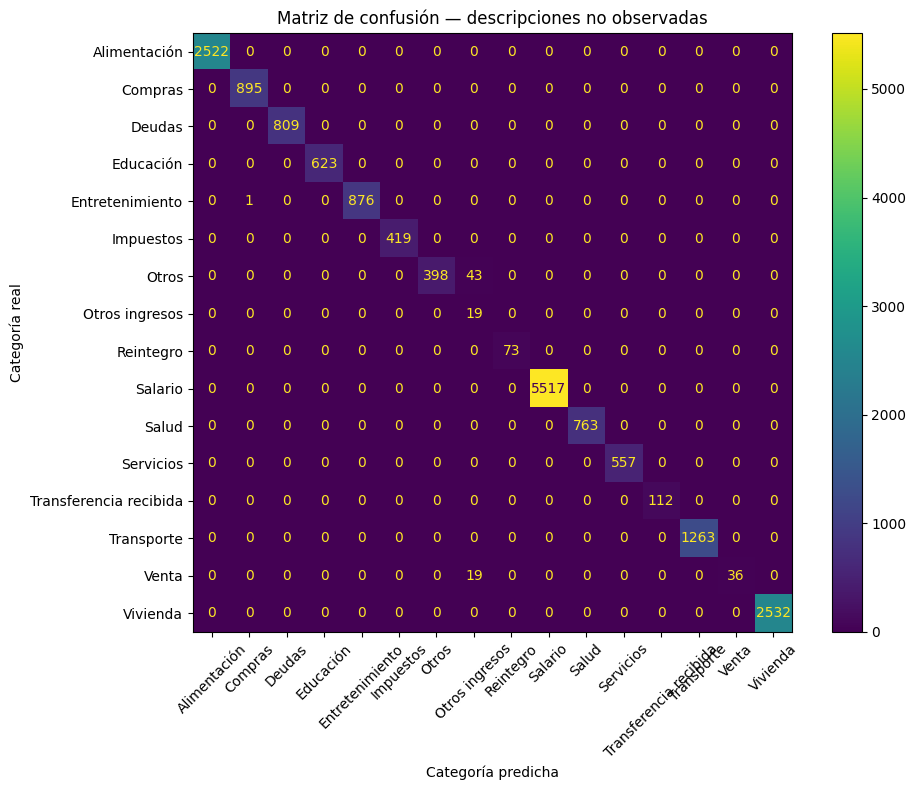

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_cat_group_test,
    pred_categoria_agrupada,
    xticks_rotation=45,
    ax=ax,
)

ax.set_title(
    "Matriz de confusión — descripciones no observadas"
)

ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")

plt.tight_layout()
plt.show()

### ***Interpretación del resultado***

Las métricas mostradas por la celda anterior deben interpretarse como una estimación de la capacidad de generalización del clasificador ante descripciones no compartidas entre entrenamiento y validación. La evaluación agrupada es más exigente que una partición aleatoria y permite detectar cuánto depende el modelo de expresiones textuales ya observadas.

La matriz de confusión y el reporte por clase permiten identificar las categorías con mayor solapamiento semántico. Una caída frente al hold-out no implica un error del pipeline: evidencia que ampliar el vocabulario sintético y sumar ejemplos lingüísticos diversos es importante para mejorar el rendimiento ante transacciones nuevas.

Los valores concretos pueden cambiar al regenerar el dataset raw; por eso esta interpretación se mantiene vinculada a las métricas calculadas en la ejecución actual y no a resultados fijos de una versión anterior.


## **16. Interpretabilidad del clasificador de transacciones**

Con el objetivo de comprender el funcionamiento interno del modelo, se analizan las variables con mayor influencia positiva en la predicción de cada categoría de gasto.

Dado que el clasificador utilizado es un `SGDClassifier` con `loss="log_loss"` (modelo lineal probabilístico), es posible inspeccionar directamente sus coeficientes y determinar cuáles son los términos y características que más contribuyen a identificar cada categoría. Este análisis aporta transparencia al modelo y facilita la validación de que las decisiones se basan en patrones coherentes del conjunto de datos.

In [27]:
modelo_categoria.fit(
    X_categoria,
    y_categoria,
)

preprocesador_entrenado = modelo_categoria.named_steps[
    "preprocesamiento"
]

clasificador_entrenado = modelo_categoria.named_steps[
    "clasificador"
]

nombres_features = (
    preprocesador_entrenado.get_feature_names_out()
)

coeficientes = clasificador_entrenado.coef_
clases_categoria = clasificador_entrenado.classes_

TOP_FEATURES = 8

filas_terminos = []

for indice_clase, clase in enumerate(clases_categoria):

    mejores_indices = np.argsort(
        coeficientes[indice_clase]
    )[-TOP_FEATURES:][::-1]

    for posicion, indice_feature in enumerate(
        mejores_indices,
        start=1,
    ):
        filas_terminos.append({
            "categoria": clase,
            "posicion": posicion,
            "feature": (
                nombres_features[indice_feature]
                .replace("texto__", "")
            ),
            "coeficiente": coeficientes[
                indice_clase,
                indice_feature,
            ],
        })

terminos_importantes = (
    pd.DataFrame(filas_terminos)
    .sort_values(
        ["categoria", "posicion"]
    )
    .reset_index(drop=True)
)

display(
    terminos_importantes.round({
        "coeficiente": 4,
    })
)

,categoria,posicion,feature,coeficiente
0,Alimentación,1,texto_palabras__comida,5.9630
1,Alimentación,2,texto_palabras__cena,5.6812
2,Alimentación,3,texto_palabras__autoservicio,5.6213
3,Alimentación,4,texto_palabras__cafe,5.5402
4,Alimentación,5,texto_palabras__gastronomico,5.3251
...,...,...,...,...
123,Vivienda,4,texto_palabras__vivienda,5.8591
124,Vivienda,5,texto_palabras__electricista,5.6214
125,Vivienda,6,texto_palabras__refaccion,5.3580
126,Vivienda,7,texto_palabras__hipoteca,5.2298


### ***Interpretación del resultado***

El análisis de los coeficientes muestra que el modelo aprendió asociaciones coherentes entre las descripciones de las transacciones y sus respectivas categorías de gasto. Los términos con mayor peso positivo corresponden a palabras representativas de cada categoría, indicando que el clasificador identifica correctamente el vocabulario característico utilizado durante el entrenamiento.

Por ejemplo, en la categoría **Alimentación** destacan términos como *verdulería*, *restaurante*, *almuerzo*, *panadería* y *carnicería*, mientras que en **Vivienda** aparecen palabras relacionadas con el hogar, como *muebles*, *hogar* y *reparación*. Este comportamiento evidencia que la representación TF-IDF logra capturar información semántica relevante para la clasificación.

La inspección de los coeficientes constituye una herramienta de interpretabilidad que permite comprender el proceso de decisión del modelo y verificar que las predicciones se sustentan en patrones consistentes con el dominio financiero, facilitando además la detección de posibles asociaciones inesperadas o sesgos durante el entrenamiento.

## **17. Modelo de clasificación del perfil financiero**

El objetivo de esta etapa es desarrollar un modelo supervisado capaz de clasificar a cada usuario en uno de los siguientes perfiles financieros:

- **Saludable**
- **En observación**
- **En riesgo**

El modelo utiliza variables financieras declaradas por el usuario, como ingresos, deuda, gastos y ahorro, junto con atributos agregados derivados de su comportamiento transaccional.

Para el procesamiento de los datos se aplican técnicas de imputación y estandarización sobre las variables numéricas, mientras que las variables categóricas son transformadas mediante codificación One-Hot. Finalmente, se emplea una Regresión Logística multiclase con ponderación balanceada.

In [28]:
# Selección de variables financieras y conductuales para el perfil.
features_perfil_numericas = [
    # Indicadores originales
    "nivel_endeudamiento",
    "porcentaje_gastos_ingreso",

    # Comportamiento transaccional
    "cantidad_transacciones",
    "cantidad_recurrentes",
    "cantidad_transacciones_grandes",
    "categorias_distintas",

    # Ratios calculados
    "ratio_deuda_ingreso_calculado",
    "ratio_gasto_ingreso_calculado",
    "ratio_ahorro_ingreso_calculado",
]

features_perfil_categoricas = [
    "frecuencia_ahorro",
]

features_perfil = (
    features_perfil_numericas
    + features_perfil_categoricas
)

target_perfil = "perfil_financiero"

X_perfil = dataset_perfiles[
    features_perfil
].copy()

y_perfil = dataset_perfiles[
    target_perfil
].copy()


preprocesador_perfil = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline([
                (
                    "imputacion",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "escalado",
                    StandardScaler(),
                ),
            ]),
            features_perfil_numericas,
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
            features_perfil_categoricas,
        ),
    ]
)


modelo_perfil = Pipeline([
    (
        "preprocesamiento",
        preprocesador_perfil,
    ),
    (
        "clasificador",
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

### **Preparación del modelo**

Se construyó un pipeline que integra variables financieras originales y atributos agregados a nivel de usuario. Las variables numéricas son imputadas mediante la mediana y posteriormente estandarizadas, mientras que la frecuencia de ahorro se transforma mediante codificación One-Hot.

La Regresión Logística utiliza ponderación balanceada para reducir el efecto del desbalance existente entre los perfiles financieros. El pipeline resultante conserva dentro del mismo artefacto tanto el preprocesamiento como el clasificador, evitando diferencias entre entrenamiento e inferencia.

Las features seleccionadas describen endeudamiento, proporción de gastos, capacidad de ahorro y comportamiento transaccional. No se incluyen saldos bancarios ni variables operativas externas al alcance analítico del proyecto.


## **18. Evaluación mediante hold-out estratificado**

El modelo de clasificación del perfil financiero se evalúa mediante una partición hold-out estratificada, utilizando el 75 % de los usuarios para entrenamiento y el 25 % restante para prueba.

La estratificación permite conservar la proporción de los perfiles financieros en ambos subconjuntos. Para medir el rendimiento se utilizan Accuracy, F1 Macro y F1 Weighted, junto con el informe de clasificación y la matriz de confusión.

In [29]:
X_perfil_train, X_perfil_test, y_perfil_train, y_perfil_test = (
    train_test_split(
        X_perfil,
        y_perfil,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_perfil,
    )
)

print(
    "Usuarios de entrenamiento:",
    len(X_perfil_train),
)
print(
    "Usuarios de prueba:",
    len(X_perfil_test),
)

modelo_perfil.fit(
    X_perfil_train,
    y_perfil_train,
)

pred_perfil_train = modelo_perfil.predict(
    X_perfil_train
)

pred_perfil = modelo_perfil.predict(
    X_perfil_test
)

accuracy_perfil_train = accuracy_score(
    y_perfil_train,
    pred_perfil_train,
)

metricas_perfil_holdout = {
    "accuracy": accuracy_score(
        y_perfil_test,
        pred_perfil,
    ),
    "precision_macro": precision_score(
        y_perfil_test,
        pred_perfil,
        average="macro",
        zero_division=0,
    ),
    "recall_macro": recall_score(
        y_perfil_test,
        pred_perfil,
        average="macro",
        zero_division=0,
    ),
    "f1_macro": f1_score(
        y_perfil_test,
        pred_perfil,
        average="macro",
    ),
    "f1_weighted": f1_score(
        y_perfil_test,
        pred_perfil,
        average="weighted",
    ),
}

metricas_perfil_overfitting = {
    "accuracy_train": accuracy_perfil_train,
    "accuracy_test": metricas_perfil_holdout["accuracy"],
    "brecha_train_test": (
        accuracy_perfil_train
        - metricas_perfil_holdout["accuracy"]
    ),
    "f1_macro_train": f1_score(
        y_perfil_train,
        pred_perfil_train,
        average="macro",
    ),
    "f1_macro_test": metricas_perfil_holdout["f1_macro"],
}

display(
    pd.Series(
        metricas_perfil_holdout,
        name="clasificacion_perfil_holdout",
    ).round(4)
)

display(
    pd.Series(
        metricas_perfil_overfitting,
        name="diagnostico_overfitting_perfil",
    ).round(4)
)

brecha_perfil = metricas_perfil_overfitting[
    "brecha_train_test"
]

if brecha_perfil <= 0.03:
    print("✅ No se observa overfitting significativo.")
elif brecha_perfil <= 0.07:
    print("⚠️ Se observa una brecha moderada entre train y test.")
else:
    print("🚨 Posible overfitting: la brecha train-test es elevada.")

print(
    classification_report(
        y_perfil_test,
        pred_perfil,
        zero_division=0,
    )
)

Usuarios de entrenamiento: 750
Usuarios de prueba: 250


,clasificacion_perfil_holdout
accuracy,0.8840
precision_macro,0.8888
recall_macro,0.8937
f1_macro,0.8895
f1_weighted,0.8852


,diagnostico_overfitting_perfil
accuracy_train,0.9093
accuracy_test,0.8840
brecha_train_test,0.0253
f1_macro_train,0.9120
f1_macro_test,0.8895


✅ No se observa overfitting significativo.
                precision    recall  f1-score   support

En observación       0.90      0.84      0.87       114
     En riesgo       0.78      0.90      0.84        69
     Saludable       0.98      0.94      0.96        67

      accuracy                           0.88       250
     macro avg       0.89      0.89      0.89       250
  weighted avg       0.89      0.88      0.89       250



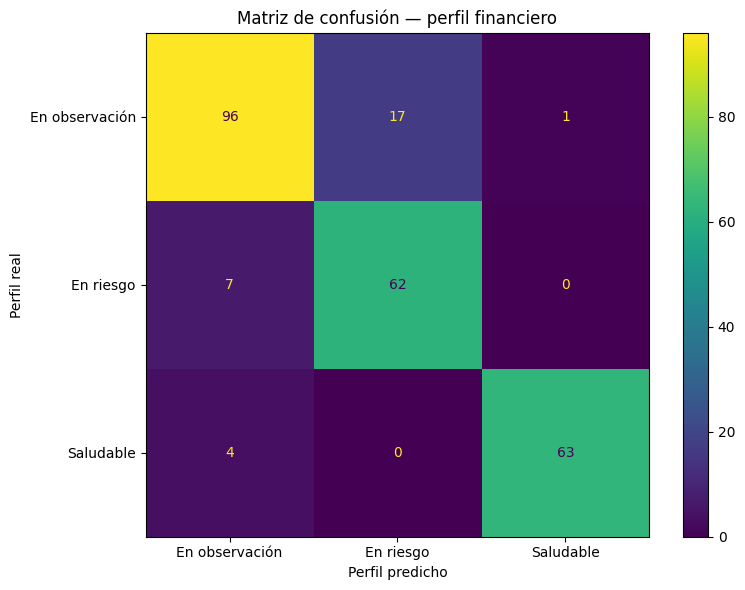

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_perfil_test,
    pred_perfil,
    ax=ax,
)

ax.set_title(
    "Matriz de confusión — perfil financiero"
)

ax.set_xlabel("Perfil predicho")
ax.set_ylabel("Perfil real")

plt.tight_layout()
plt.show()

### ***Interpretación del resultado***

La evaluación hold-out permite medir el desempeño inicial del clasificador de perfil sobre usuarios no utilizados durante el entrenamiento. Deben analizarse conjuntamente accuracy, F1 Macro, F1 Weighted, el reporte por clase y la matriz de confusión para verificar que el modelo no concentre su rendimiento únicamente en la clase mayoritaria.

Las métricas concretas corresponden al dataset generado y ejecutado en esta versión. Al regenerar los datos pueden variar, por lo que la interpretación debe apoyarse en los resultados producidos por la celda anterior y no en cifras heredadas de una corrida previa.

El modelo caracteriza al usuario mediante endeudamiento, proporción de gastos, capacidad de ahorro y comportamiento transaccional.


### **Limitación de la evaluación hold-out**

El conjunto de prueba está compuesto por **250 usuarios**, mientras que el entrenamiento utiliza **750 usuarios**. Aunque esta partición proporciona una estimación confiable del rendimiento del modelo, las métricas obtenidas siguen dependiendo de una única división del conjunto de datos.

Por este motivo, la evaluación hold-out se complementa en la siguiente sección con una validación cruzada estratificada, que utiliza múltiples particiones de los usuarios y permite obtener una estimación más robusta y estable del desempeño del clasificador.

## **19. Validación cruzada estratificada**

Como complemento de la evaluación hold-out, se aplica una validación cruzada estratificada de cinco pliegues (5-Fold Stratified Cross Validation).

En cada iteración, el modelo se entrena utilizando una partición diferente del conjunto de usuarios y se evalúa sobre el pliegue restante, preservando la proporción de los perfiles financieros en todas las divisiones. Esta metodología proporciona una estimación más robusta y estable del rendimiento del clasificador, reduciendo la dependencia de una única partición de entrenamiento y prueba.

In [31]:
cv_perfil = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados_cv_perfil = cross_validate(
    estimator=modelo_perfil,
    X=X_perfil,
    y=y_perfil,
    cv=cv_perfil,
    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
    },
    return_train_score=False,
    n_jobs=None,
)

metricas_cv_perfil = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
]

resumen_cv_perfil = pd.DataFrame({
    "metrica": metricas_cv_perfil,
    "promedio": [
        resultados_cv_perfil[f"test_{metrica}"].mean()
        for metrica in metricas_cv_perfil
    ],
    "desvio_estandar": [
        resultados_cv_perfil[f"test_{metrica}"].std()
        for metrica in metricas_cv_perfil
    ],
})

display(resumen_cv_perfil.round(4))

,metrica,promedio,desvio_estandar
0,accuracy,0.9000,0.0170
1,precision_macro,0.8991,0.0171
2,recall_macro,0.9121,0.0146
3,f1_macro,0.9031,0.0158
4,f1_weighted,0.8996,0.0172


### ***Interpretación del resultado***

La validación cruzada estratificada complementa el hold-out al repetir el entrenamiento y la evaluación sobre cinco particiones distintas. El promedio resume el rendimiento esperado, mientras que la desviación estándar permite observar su estabilidad frente a cambios en la muestra.

La comparación entre hold-out y validación cruzada ayuda a detectar resultados demasiado dependientes de una única partición. Los valores deben leerse directamente de la salida de esta ejecución, ya que el dataset sintético y los modelos se regeneran en cada nueva versión del pipeline.


## **20. Interpretabilidad del modelo de perfil financiero**

Con el objetivo de comprender el funcionamiento del clasificador, se analizan las variables con mayor influencia positiva en la predicción de cada perfil financiero.

Al utilizar una Regresión Logística multiclase, es posible inspeccionar directamente los coeficientes del modelo para identificar qué variables financieras y atributos derivados del comportamiento transaccional contribuyen con mayor intensidad a la clasificación de cada perfil. Este análisis aporta interpretabilidad y permite verificar que las decisiones del modelo se fundamentan en patrones consistentes con el dominio financiero.

In [32]:
modelo_perfil.fit(
    X_perfil,
    y_perfil,
)

preprocesador_perfil_entrenado = (
    modelo_perfil.named_steps[
        "preprocesamiento"
    ]
)

clasificador_perfil_entrenado = (
    modelo_perfil.named_steps[
        "clasificador"
    ]
)

nombres_features_perfil = (
    preprocesador_perfil_entrenado.get_feature_names_out()
)

coeficientes_perfil = (
    clasificador_perfil_entrenado.coef_
)

clases_perfil = (
    clasificador_perfil_entrenado.classes_
)

TOP_FEATURES = 8

filas_importancia_perfil = []

for indice_clase, clase in enumerate(clases_perfil):

    mejores_indices = np.argsort(
        coeficientes_perfil[indice_clase]
    )[-TOP_FEATURES:][::-1]

    for posicion, indice_feature in enumerate(
        mejores_indices,
        start=1,
    ):
        nombre_feature = (
            nombres_features_perfil[indice_feature]
            .replace("numericas__", "")
            .replace("categoricas__", "")
        )

        filas_importancia_perfil.append({
            "perfil": clase,
            "posicion": posicion,
            "feature": nombre_feature,
            "coeficiente": coeficientes_perfil[
                indice_clase,
                indice_feature,
            ],
        })

importancia_perfil = (
    pd.DataFrame(filas_importancia_perfil)
    .sort_values(
        ["perfil", "posicion"]
    )
    .reset_index(drop=True)
)

display(
    importancia_perfil.round({
        "coeficiente": 4,
    })
)

,perfil,posicion,feature,coeficiente
0,En observación,1,frecuencia_ahorro_Alta,2.3772
1,En observación,2,porcentaje_gastos_ingreso,1.0799
2,En observación,3,ratio_gasto_ingreso_calculado,1.0793
3,En observación,4,frecuencia_ahorro_Media,0.4060
4,En observación,5,cantidad_transacciones,0.1227
5,En observación,6,nivel_endeudamiento,0.1102
6,En observación,7,ratio_deuda_ingreso_calculado,0.1094
7,En observación,8,cantidad_transacciones_grandes,-0.1074
8,En riesgo,1,frecuencia_ahorro_Baja,1.7732
9,En riesgo,2,ratio_deuda_ingreso_calculado,1.2708


### ***Interpretación del resultado***

El análisis de los coeficientes muestra que el modelo fundamenta sus decisiones en variables financieras coherentes con la definición de cada perfil. En el perfil **En riesgo** predominan indicadores relacionados con el endeudamiento, como la **deuda mensual**, el **nivel de endeudamiento**, el **ratio gasto/ingreso** y el **porcentaje de gastos sobre los ingresos**, además de la ausencia de hábitos de ahorro (*frecuencia_ahorro = Nunca*). Estas variables reflejan un comportamiento financiero de mayor vulnerabilidad.

Para el perfil **Saludable**, las variables con mayor influencia están asociadas a una situación financiera equilibrada, destacándose el **ratio ahorro/ingreso**, el **ahorro mensual estimado** y una **frecuencia de ahorro alta**, lo que evidencia la importancia de la capacidad de ahorro en la clasificación realizada por el modelo.

Por su parte, el perfil **En observación** presenta un comportamiento intermedio, caracterizado principalmente por una **frecuencia de ahorro media**, un nivel moderado de endeudamiento y un porcentaje de gastos sobre los ingresos superior al observado en los usuarios clasificados como saludables, aunque sin alcanzar los valores característicos del perfil de mayor riesgo.

En conjunto, estos resultados indican que el modelo no basa sus decisiones en variables arbitrarias, sino en indicadores financieros consistentes con la lógica utilizada para construir los perfiles del conjunto de datos. La inspección de los coeficientes aporta transparencia al proceso de clasificación y facilita la interpretación del comportamiento del modelo.

## **21. Inferencia, recomendaciones y contrato JSON**

Esta sección simula el comportamiento esperado de los modelos en un entorno de producción. El backend puede enviar los datos de una transacción o solicitar el análisis de un usuario y recibir una respuesta estructurada en formato JSON.

Para la clasificación de transacciones se reutilizan las mismas reglas de normalización textual aplicadas durante el entrenamiento. Para el análisis de usuario se combinan la predicción del perfil, las métricas financieras, las principales categorías de gasto y recomendaciones basadas en reglas explicables.

El contrato de salida se limita a información analítica. No administra cuentas, saldos, transferencias ni reservas de dinero.


In [33]:
def preparar_transaccion_inferencia(
    descripcion: str,
    monto: float,
    fecha: str,
    medio_pago: str,
    recurrente: str,
) -> pd.DataFrame:
    if not descripcion or not descripcion.strip():
        raise ValueError(
            "La descripción no puede estar vacía."
        )

    if monto <= 0:
        raise ValueError(
            "El monto debe ser mayor que cero."
        )

    pd.Timestamp(fecha)

    return pd.DataFrame([{
        "descripcion_limpia": normalizar_texto(
            descripcion
        ),
    }])


def predecir_categoria(
    descripcion: str,
    monto: float,
    fecha: str,
    medio_pago: str,
    recurrente: str,
) -> dict:
    entrada = preparar_transaccion_inferencia(
        descripcion=descripcion,
        monto=monto,
        fecha=fecha,
        medio_pago=medio_pago,
        recurrente=recurrente,
    )

    categoria_predicha = str(
        modelo_categoria_produccion.predict(entrada)[0]
    )

    probabilidades = (
        modelo_categoria_produccion.predict_proba(entrada)[0]
    )

    probabilidades_por_categoria = {
        str(clase): round(float(probabilidad), 4)
        for clase, probabilidad in zip(
            modelo_categoria_produccion.classes_,
            probabilidades,
        )
    }

    categorias_ingreso = {
        "Reintegro",
        "Salario",
        "Transferencia recibida",
        "Venta",
    }

    tipo_transaccion = (
        "INGRESO"
        if categoria_predicha in categorias_ingreso
        else "GASTO"
    )

    return {
        "tipo_transaccion": tipo_transaccion,
        "categoria_predicha": categoria_predicha,
        "confianza": probabilidades_por_categoria[
            categoria_predicha
        ],
        "probabilidades": probabilidades_por_categoria,
    }


In [34]:
resultado_categoria = predecir_categoria(
    descripcion="Compra en verdulería",
    monto=42.50,
    fecha="2026-07-18",
    medio_pago="Tarjeta de débito",
    recurrente="No",
)

print(
    json.dumps(
        resultado_categoria,
        indent=4,
        ensure_ascii=False,
    )
)

{
    "tipo_transaccion": "GASTO",
    "categoria_predicha": "Alimentación",
    "confianza": 0.9996,
    "probabilidades": {
        "Alimentación": 0.9996,
        "Compras": 0.0001,
        "Deudas": 0.0,
        "Educación": 0.0,
        "Entretenimiento": 0.0,
        "Impuestos": 0.0,
        "Otros": 0.0,
        "Otros ingresos": 0.0001,
        "Reintegro": 0.0,
        "Salario": 0.0,
        "Salud": 0.0,
        "Servicios": 0.0,
        "Transferencia recibida": 0.0,
        "Transporte": 0.0,
        "Venta": 0.0,
        "Vivienda": 0.0
    }
}


### ***Interpretación del contrato de salida***

La función devuelve una respuesta estructurada en formato JSON, compatible con su integración en un servicio web. Además de la categoría predicha, se incluyen la confianza asociada a la predicción y la distribución de probabilidades para todas las categorías posibles.

Este formato permite que el backend consuma directamente el resultado generado por el modelo y lo exponga mediante una API REST. La información de confianza y las probabilidades también pueden utilizarse para implementar reglas de negocio, como solicitar la confirmación del usuario cuando la predicción presente un bajo nivel de certeza o registrar casos para su posterior análisis.

## **22. Casos de uso para clasificación de transacciones**

In [35]:
casos_transacciones = [
    {
        "descripcion": "Compra semanal en supermercado",
        "monto": 85.40,
        "fecha": "2026-07-16",
        "medio_pago": "Billetera virtual",
        "recurrente": "No",
    },
    {
        "descripcion": "Pago de plataforma de streaming",
        "monto": 14.99,
        "fecha": "2026-07-12",
        "medio_pago": "Débito automático",
        "recurrente": "Sí",
    },
    {
        "descripcion": "Consulta médica y medicamentos",
        "monto": 72.50,
        "fecha": "2026-07-15",
        "medio_pago": "Tarjeta de crédito",
        "recurrente": "No",
    },
]

resultados_casos = []

for caso in casos_transacciones:
    resultado = predecir_categoria(**caso)

    resultados_casos.append({
        **caso,
        **resultado,
    })

display(
    pd.DataFrame(resultados_casos)
)

,descripcion,monto,fecha,medio_pago,recurrente,tipo_transaccion,categoria_predicha,confianza,probabilidades
0,Compra semanal en supermercado,85.4000,2026-07-16,Billetera virtual,No,GASTO,Alimentación,0.9990,"{'Alimentación': 0.999, 'Compras': 0.0, 'Deuda..."
1,Pago de plataforma de streaming,14.9900,2026-07-12,Débito automático,Sí,GASTO,Entretenimiento,0.8696,"{'Alimentación': 0.0001, 'Compras': 0.0, 'Deud..."
2,Consulta médica y medicamentos,72.5000,2026-07-15,Tarjeta de crédito,No,GASTO,Salud,0.9997,"{'Alimentación': 0.0, 'Compras': 0.0, 'Deudas'..."


### ***Interpretación de los casos de uso***

Los tres ejemplos simulan transacciones que podrían ser enviadas por el backend al servicio de Ciencia de Datos. Para cada caso, el pipeline aplica la limpieza textual, genera las variables necesarias y devuelve una categoría predicha junto con su nivel de confianza y la distribución de probabilidades.

Esta prueba permite verificar que el modelo puede procesar múltiples transacciones con diferentes descripciones, montos, fechas y medios de pago utilizando el mismo contrato de entrada y salida definido para la integración con la API.

## **23. Análisis integral del usuario y generación de recomendaciones**

Esta sección integra el modelo de perfil financiero con indicadores económicos, categorías principales de gasto y reglas de recomendación.

A partir del identificador de un usuario, se recuperan sus características financieras, se predice su perfil, se calculan sus principales categorías de gasto y se generan recomendaciones personalizadas. El resultado se devuelve mediante una estructura compatible con JSON para facilitar su consumo desde el backend.

In [36]:
def generar_recomendaciones(
    fila_usuario: pd.Series,
) -> list[str]:
    recomendaciones = []

    ratio_gasto = float(
        fila_usuario[
            "ratio_gasto_ingreso_calculado"
        ]
    )

    ratio_deuda = float(
        fila_usuario[
            "ratio_deuda_ingreso_calculado"
        ]
    )

    ratio_ahorro = float(
        fila_usuario[
            "ratio_ahorro_ingreso_calculado"
        ]
    )

    recurrentes = int(
        fila_usuario["cantidad_recurrentes"]
    )

    if ratio_gasto >= 0.80:
        recomendaciones.append(
            "Reducir los gastos mensuales y priorizar las categorías esenciales."
        )
    elif ratio_gasto >= 0.60:
        recomendaciones.append(
            "Revisar las categorías de mayor consumo para liberar capacidad de ahorro."
        )
    else:
        recomendaciones.append(
            "Mantener el nivel de gasto actual y revisar el presupuesto periódicamente."
        )

    if ratio_deuda >= 0.35:
        recomendaciones.append(
            "Priorizar la reducción de deuda antes de asumir nuevos compromisos financieros."
        )
    elif ratio_deuda >= 0.20:
        recomendaciones.append(
            "Evitar incrementar la deuda y planificar pagos anticipados cuando sea posible."
        )
    else:
        recomendaciones.append(
            "El nivel de endeudamiento se encuentra controlado."
        )

    if ratio_ahorro < 0.10:
        recomendaciones.append(
            "Definir un objetivo inicial de ahorro de al menos el 10% del ingreso mensual."
        )
    elif ratio_ahorro < 0.20:
        recomendaciones.append(
            "Incrementar gradualmente el porcentaje destinado al ahorro."
        )
    else:
        recomendaciones.append(
            "Mantener el hábito de ahorro y considerar la construcción de un fondo de emergencia."
        )

    if recurrentes >= 15:
        recomendaciones.append(
            "Auditar suscripciones y débitos automáticos para detectar cargos innecesarios."
        )

    return recomendaciones

In [37]:
def analizar_usuario(
    usuario_id: str,
) -> dict:
    coincidencias = dataset_perfiles[
        dataset_perfiles["usuario_id"]
        == usuario_id
    ]

    if coincidencias.empty:
        raise ValueError(
            f"No existe el usuario {usuario_id}."
        )

    fila = coincidencias.iloc[0]

    entrada_perfil = (
        fila[features_perfil]
        .to_frame()
        .T
    )

    perfil_predicho = modelo_perfil.predict(
        entrada_perfil
    )[0]

    probabilidades = modelo_perfil.predict_proba(
        entrada_perfil
    )[0]

    clases = modelo_perfil.classes_

    probabilidades_perfil = {
        str(clase): round(
            float(probabilidad),
            4,
        )
        for clase, probabilidad in zip(
            clases,
            probabilidades,
        )
    }

    confianza_perfil = probabilidades_perfil[
        str(perfil_predicho)
    ]

    # Se consideran únicamente los gastos
    gastos_usuario = transacciones_features[
        (
            transacciones_features["usuario_id"]
            == usuario_id
        )
        & (
            transacciones_features["tipo"]
            == "GASTO"
        )
    ].copy()

    categorias_principales = (
        gastos_usuario
        .groupby("categoria")["monto"]
        .sum()
        .sort_values(ascending=False)
        .head(3)
    )

    total_gastado = float(
        gastos_usuario["monto"].sum()
    )

    categorias_json = []

    for categoria, monto in categorias_principales.items():
        porcentaje = (
            float(monto) / total_gastado * 100
            if total_gastado > 0
            else 0.0
        )

        categorias_json.append({
            "categoria": str(categoria),
            "monto": round(
                float(monto),
                2,
            ),
            "porcentaje": round(
                porcentaje,
                2,
            ),
        })

    return {
        "usuario_id": str(usuario_id),
        "perfil_financiero": str(
            perfil_predicho
        ),
        "confianza_perfil": confianza_perfil,
        "probabilidades_perfil": (
            probabilidades_perfil
        ),
        "metricas": {
            "ingreso_mensual": round(
                float(
                    fila["ingreso_mensual"]
                ),
                2,
            ),
            "gasto_mensual_promedio": round(
                float(
                    fila[
                        "gasto_mensual_promedio"
                    ]
                ),
                2,
            ),
            "deuda_mensual": round(
                float(
                    fila["deuda_mensual"]
                ),
                2,
            ),
            "ahorro_mensual_estimado": round(
                float(
                    fila[
                        "ahorro_mensual_estimado"
                    ]
                ),
                2,
            ),
            "ratio_gasto_ingreso": round(
                float(
                    fila[
                        "ratio_gasto_ingreso_calculado"
                    ]
                ),
                4,
            ),
            "ratio_deuda_ingreso": round(
                float(
                    fila[
                        "ratio_deuda_ingreso_calculado"
                    ]
                ),
                4,
            ),
            "ratio_ahorro_ingreso": round(
                float(
                    fila[
                        "ratio_ahorro_ingreso_calculado"
                    ]
                ),
                4,
            ),
        },
        "total_gastado_periodo": round(
            total_gastado,
            2,
        ),
        "categorias_principales_gasto": (
            categorias_json
        ),
        "recomendaciones": (
            generar_recomendaciones(fila)
        ),
        "modelo_version": VERSION_MODELOS,
    }

In [38]:
usuario_ejemplo = dataset_perfiles[
    "usuario_id"
].iloc[0]

resultado_usuario = analizar_usuario(
    usuario_ejemplo
)

print(
    json.dumps(
        resultado_usuario,
        indent=4,
        ensure_ascii=False,
    )
)

{
    "usuario_id": "USR0001",
    "perfil_financiero": "En riesgo",
    "confianza_perfil": 0.6975,
    "probabilidades_perfil": {
        "En observación": 0.3025,
        "En riesgo": 0.6975,
        "Saludable": 0.0
    },
    "metricas": {
        "ingreso_mensual": 3229.87,
        "gasto_mensual_promedio": 2790.94,
        "deuda_mensual": 548.36,
        "ahorro_mensual_estimado": 438.93,
        "ratio_gasto_ingreso": 0.8641,
        "ratio_deuda_ingreso": 0.1698,
        "ratio_ahorro_ingreso": 0.1359
    },
    "total_gastado_periodo": 33491.28,
    "categorias_principales_gasto": [
        {
            "categoria": "Educación",
            "monto": 9722.36,
            "porcentaje": 29.03
        },
        {
            "categoria": "Vivienda",
            "monto": 8250.31,
            "porcentaje": 24.63
        },
        {
            "categoria": "Deudas",
            "monto": 7792.04,
            "porcentaje": 23.27
        }
    ],
    "recomendaciones": [
        "

### ***Interpretación del resultado***

La función integra la predicción del perfil financiero con indicadores económicos, categorías principales de gasto y recomendaciones generadas mediante reglas de negocio.

El contrato puede ser consumido por el backend para construir paneles personalizados, explicar la situación financiera del usuario y ofrecer sugerencias adaptadas a sus hábitos.

Las categorías principales se calculan exclusivamente a partir de las transacciones de gasto, mientras que la predicción del perfil considera conjuntamente ingresos, gastos, nivel de endeudamiento, capacidad de ahorro y comportamiento transaccional. Esta integración demuestra cómo los modelos pueden incorporarse dentro de una arquitectura orientada a servicios sin convertir la aplicación en una billetera o sistema de administración de dinero.


## **24. Tres ejemplos completos de análisis de usuario**

In [39]:
usuarios_demo = [
    "USR0001",
    "USR0004",
    "USR0008",
]

analisis_demo = [
    analizar_usuario(usuario_id)
    for usuario_id in usuarios_demo
]

for resultado in analisis_demo:
    print(json.dumps(
        resultado,
        ensure_ascii=False,
        indent=2,
    ))
    print("-" * 80)

{
  "usuario_id": "USR0001",
  "perfil_financiero": "En riesgo",
  "confianza_perfil": 0.6975,
  "probabilidades_perfil": {
    "En observación": 0.3025,
    "En riesgo": 0.6975,
    "Saludable": 0.0
  },
  "metricas": {
    "ingreso_mensual": 3229.87,
    "gasto_mensual_promedio": 2790.94,
    "deuda_mensual": 548.36,
    "ahorro_mensual_estimado": 438.93,
    "ratio_gasto_ingreso": 0.8641,
    "ratio_deuda_ingreso": 0.1698,
    "ratio_ahorro_ingreso": 0.1359
  },
  "total_gastado_periodo": 33491.28,
  "categorias_principales_gasto": [
    {
      "categoria": "Educación",
      "monto": 9722.36,
      "porcentaje": 29.03
    },
    {
      "categoria": "Vivienda",
      "monto": 8250.31,
      "porcentaje": 24.63
    },
    {
      "categoria": "Deudas",
      "monto": 7792.04,
      "porcentaje": 23.27
    }
  ],
  "recomendaciones": [
    "Reducir los gastos mensuales y priorizar las categorías esenciales.",
    "El nivel de endeudamiento se encuentra controlado.",
    "Incrementar

### ***Interpretación***

Los ejemplos anteriores muestran el funcionamiento del servicio de análisis financiero a nivel de usuario. Para cada identificador se integran las métricas financieras, la predicción del perfil, las categorías principales de gasto y las recomendaciones generadas mediante reglas de negocio.

Este formato representa la respuesta que consumiría el backend de FinSightAI para construir paneles personalizados y ofrecer recomendaciones financieras adaptadas a cada usuario.

## **25. Serialización y verificación de artefactos**

Se guardan los modelos completos, incluyendo preprocesamiento y clasificador, junto con metadatos, métricas y ejemplos JSON.

### **Pruebas de robustez y confianza**

Antes de exportar el modelo se ejecuta una batería pequeña de frases claras, errores ortográficos y descripciones ambiguas. Estas pruebas no sustituyen las métricas del conjunto de test; funcionan como **smoke tests** para detectar regresiones evidentes en el comportamiento del clasificador.


In [40]:
casos_smoke_test = [
    "Compra en supermercado",
    "Consulta médica",
    "Pago de alquiler",
    "Curso online",
    "Viaje por aplicación",
    "Compra por internet",
    "vrduleria",
    "vetrinaria",
    "farmcia",
    "Pago",
]

filas_smoke = []

for descripcion_prueba in casos_smoke_test:
    entrada_prueba = pd.DataFrame([
        {
            "descripcion_limpia": normalizar_texto(
                descripcion_prueba
            )
        }
    ])

    pred = str(
        modelo_categoria_produccion.predict(
            entrada_prueba
        )[0]
    )

    proba = modelo_categoria_produccion.predict_proba(
        entrada_prueba
    )[0]

    confianza = float(
        np.max(proba)
    )

    filas_smoke.append({
        "descripcion": descripcion_prueba,
        "categoria_predicha": pred,
        "confianza": confianza,
    })

smoke_test_resultados = pd.DataFrame(
    filas_smoke
)

display(
    smoke_test_resultados.round({
        "confianza": 4,
    })
)

print(
    "Nota: una descripción deliberadamente ambigua como "
    "'Pago' puede y debe conservar una confianza baja."
)


,descripcion,categoria_predicha,confianza
0,Compra en supermercado,Alimentación,0.9994
1,Consulta médica,Salud,0.9996
2,Pago de alquiler,Vivienda,0.9993
3,Curso online,Educación,0.9975
4,Viaje por aplicación,Transporte,0.9995
5,Compra por internet,Compras,0.9940
6,vrduleria,Alimentación,0.9984
7,vetrinaria,Salud,0.9536
8,farmcia,Salud,0.9859
9,Pago,Deudas,0.4099


Nota: una descripción deliberadamente ambigua como 'Pago' puede y debe conservar una confianza baja.


In [41]:
print("Serializando modelos...")

RUTA_MODELO_CATEGORIA = (
    MODELS_DIR / "clasificador_gastos.joblib"
)
RUTA_MODELO_PERFIL = (
    MODELS_DIR / "clasificador_perfil.joblib"
)
RUTA_METADATA = (
    ARTIFACTS_DIR / "metadata_modelos.json"
)
RUTA_METRICAS = (
    ARTIFACTS_DIR / "metricas_modelos.csv"
)
RUTA_EJEMPLOS_JSON = (
    ARTIFACTS_DIR
    / "ejemplos_respuesta_backend.json"
)

# ============================
# Modelos
# ============================

joblib.dump(
    modelo_categoria_produccion,
    RUTA_MODELO_CATEGORIA,
)
joblib.dump(
    modelo_perfil,
    RUTA_MODELO_PERFIL,
)

# ============================
# Métricas
# ============================

metricas_finales = pd.DataFrame([
    {
        "modelo": (
            "Clasificación de transacciones "
            "(Hold-Out)"
        ),
        **metricas_categoria_holdout,
        "accuracy_train": (
            metricas_categoria_overfitting[
                "accuracy_train"
            ]
        ),
        "accuracy_test": (
            metricas_categoria_overfitting[
                "accuracy_test"
            ]
        ),
        "brecha_train_test": (
            metricas_categoria_overfitting[
                "brecha_train_test"
            ]
        ),
    },
    {
        "modelo": (
            "Clasificación de transacciones "
            "(CV agrupada)"
        ),
        "accuracy": (
            resultados_cv_categoria[
                "test_accuracy"
            ].mean()
        ),
        "precision_macro": (
            resultados_cv_categoria[
                "test_precision_macro"
            ].mean()
        ),
        "recall_macro": (
            resultados_cv_categoria[
                "test_recall_macro"
            ].mean()
        ),
        "f1_macro": (
            resultados_cv_categoria[
                "test_f1_macro"
            ].mean()
        ),
        "f1_weighted": (
            resultados_cv_categoria[
                "test_f1_weighted"
            ].mean()
        ),
        "accuracy_train": pd.NA,
        "accuracy_test": pd.NA,
        "brecha_train_test": pd.NA,
    },
    {
        "modelo": "Perfil financiero (Hold-Out)",
        **metricas_perfil_holdout,
        "accuracy_train": (
            metricas_perfil_overfitting[
                "accuracy_train"
            ]
        ),
        "accuracy_test": (
            metricas_perfil_overfitting[
                "accuracy_test"
            ]
        ),
        "brecha_train_test": (
            metricas_perfil_overfitting[
                "brecha_train_test"
            ]
        ),
    },
    {
        "modelo": (
            "Perfil financiero "
            "(Validación Cruzada)"
        ),
        "accuracy": (
            resultados_cv_perfil[
                "test_accuracy"
            ].mean()
        ),
        "precision_macro": (
            resultados_cv_perfil[
                "test_precision_macro"
            ].mean()
        ),
        "recall_macro": (
            resultados_cv_perfil[
                "test_recall_macro"
            ].mean()
        ),
        "f1_macro": (
            resultados_cv_perfil[
                "test_f1_macro"
            ].mean()
        ),
        "f1_weighted": (
            resultados_cv_perfil[
                "test_f1_weighted"
            ].mean()
        ),
        "accuracy_train": pd.NA,
        "accuracy_test": pd.NA,
        "brecha_train_test": pd.NA,
    },
])

metricas_finales.to_csv(
    RUTA_METRICAS,
    index=False,
)

# ============================
# Metadata
# ============================

metadata = {
    "version": VERSION_MODELOS,
    "notebook_version": VERSION_NOTEBOOK,
    "random_state": RANDOM_STATE,
    "modelo_categoria": {
        "archivo": str(RUTA_MODELO_CATEGORIA),
        "features": features_categoria,
        "clases": list(
            modelo_categoria.classes_
        ),
    },
    "modelo_perfil": {
        "archivo": str(RUTA_MODELO_PERFIL),
        "features": features_perfil,
        "clases": list(
            modelo_perfil.classes_
        ),
    },
    "contrato_usuario_id": "Formato USRXXXX",
    "nota": (
        "Los modelos fueron entrenados con "
        "datos sintéticos. Antes de un entorno "
        "productivo deberán reentrenarse y "
        "validarse utilizando datos reales."
    ),
}

with open(
    RUTA_METADATA,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

# ============================
# Ejemplos JSON
# ============================

with open(
    RUTA_EJEMPLOS_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        analisis_demo,
        file,
        ensure_ascii=False,
        indent=2,
    )

# ============================
# Resumen
# ============================

display(metricas_finales.round(4))

print("\nArtefactos generados:\n")
print(RUTA_MODELO_CATEGORIA)
print(RUTA_MODELO_PERFIL)
print(RUTA_METADATA)
print(RUTA_METRICAS)
print(RUTA_EJEMPLOS_JSON)

Serializando modelos...


,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,accuracy_train,accuracy_test,brecha_train_test
0,Clasificación de transacciones (Hold-Out),1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
1,Clasificación de transacciones (CV agrupada),0.9967,0.9858,0.9771,0.9767,0.9968,<NA>,<NA>,<NA>
2,Perfil financiero (Hold-Out),0.8840,0.8888,0.8937,0.8895,0.8852,0.9093,0.8840,0.0253
3,Perfil financiero (Validación Cruzada),0.9000,0.8991,0.9121,0.9031,0.8996,<NA>,<NA>,<NA>



Artefactos generados:

artefactos_financeai_v10/modelos/clasificador_gastos.joblib
artefactos_financeai_v10/modelos/clasificador_perfil.joblib
artefactos_financeai_v10/metadata_modelos.json
artefactos_financeai_v10/metricas_modelos.csv
artefactos_financeai_v10/ejemplos_respuesta_backend.json


## **26. Prueba de recarga**

La serialización se considera completa únicamente si los modelos pueden cargarse nuevamente desde disco y producir predicciones válidas.

En esta sección se verifican los artefactos generados mediante `joblib`, se cargan ambos modelos y se ejecutan predicciones de prueba utilizando el mismo contrato de entrada definido para la inferencia.

In [42]:
# ============================
# Recarga de modelos
# ============================

modelo_categoria_recargado = joblib.load(
    RUTA_MODELO_CATEGORIA
)

modelo_perfil_recargado = joblib.load(
    RUTA_MODELO_PERFIL
)

print("Modelos cargados correctamente.")


# ============================
# Prueba del clasificador de transacciones
# ============================

transaccion_prueba = preparar_transaccion_inferencia(
    descripcion="Compra en supermercado",
    monto=18500,
    fecha="2026-07-17",
    medio_pago="Tarjeta de débito",
    recurrente="No",
)

categoria_recargada = (
    modelo_categoria_recargado
    .predict(transaccion_prueba)[0]
)

probabilidades_categoria = (
    modelo_categoria_recargado
    .predict_proba(transaccion_prueba)[0]
)

resultado_categoria_recarga = {
    "categoria_predicha": categoria_recargada,
    "confianza": float(
        probabilidades_categoria.max()
    ),
}

print("\nClasificador de gastos:")
print(json.dumps(
    resultado_categoria_recarga,
    ensure_ascii=False,
    indent=2,
))


# ============================
# Prueba del modelo de perfil
# ============================

usuario_prueba_id = "USR0001"

fila_usuario_prueba = dataset_perfiles.loc[
    dataset_perfiles["usuario_id"] == usuario_prueba_id,
    features_perfil,
].copy()

if fila_usuario_prueba.empty:
    raise ValueError(
        f"No se encontró el usuario {usuario_prueba_id}."
    )

perfil_recargado = (
    modelo_perfil_recargado
    .predict(fila_usuario_prueba)[0]
)

probabilidades_perfil = (
    modelo_perfil_recargado
    .predict_proba(fila_usuario_prueba)[0]
)

resultado_perfil_recarga = {
    "modelo_version": VERSION_MODELOS,
    "usuario_id": usuario_prueba_id,
    "perfil_predicho": perfil_recargado,
    "confianza": float(
        probabilidades_perfil.max()
    ),
}

print("\nClasificador de perfil financiero:")
print(json.dumps(
    resultado_perfil_recarga,
    ensure_ascii=False,
    indent=2,
))

Modelos cargados correctamente.

Clasificador de gastos:
{
  "categoria_predicha": "Alimentación",
  "confianza": 0.9993969754298287
}

Clasificador de perfil financiero:
{
  "modelo_version": "10.0.0",
  "usuario_id": "USR0001",
  "perfil_predicho": "En riesgo",
  "confianza": 0.6975005026398381
}


In [43]:
assert categoria_recargada is not None
assert perfil_recargado is not None

print(
    "\n✅ Verificación completada: "
    "los modelos fueron recargados y generaron predicciones."
)


✅ Verificación completada: los modelos fueron recargados y generaron predicciones.


### ***Interpretación***

La prueba de recarga confirma que los modelos serializados pueden recuperarse correctamente desde disco y utilizarse para realizar nuevas predicciones sin necesidad de repetir el entrenamiento.

Esta verificación garantiza que los artefactos generados contienen tanto el preprocesamiento como el clasificador entrenado, lo que permite reutilizarlos posteriormente desde el microservicio desarrollado con FastAPI.

## Clasificador complementario de subcategorías

El modelo principal de transacciones continúa prediciendo la **categoría financiera**.  
Como etapa posterior, se incorpora un clasificador complementario que utiliza la
**descripción de la transacción junto con la categoría predicha** para estimar la
**subcategoría**.

Esta separación mantiene el pipeline jerárquico:

`descripción → categoría → subcategoría`

La evaluación se realiza con separación por usuario (`GroupShuffleSplit`) para evitar
que movimientos de un mismo usuario aparezcan simultáneamente en entrenamiento y prueba.
Además, se informa una evaluación adicional sobre combinaciones categoría/descripción
no vistas durante el entrenamiento, para observar mejor la capacidad de generalización
sobre el dataset sintético.


Transacciones: 74,532
Categorías: 16
Subcategorías: 88

=== HOLD-OUT AGRUPADO POR USUARIO ===
Train: 59,614
Test: 14,918
Usuarios compartidos: 0
Accuracy: 0.9999
F1 macro: 0.9998

                           precision    recall  f1-score   support

                    Agua       0.96      1.00      0.98        23
      Almacén y despensa       1.00      1.00      1.00       136
                Alquiler       1.00      1.00      1.00       172
         Atención médica       1.00      1.00      1.00        30
               Cafetería       1.00      1.00      1.00        25
                 Calzado       1.00      1.00      1.00        42
              Carnicería       1.00      1.00      1.00        66
                    Cine       1.00      1.00      1.00        18
             Combustible       1.00      1.00      1.00        69
    Comercio electrónico       1.00      1.00      1.00        85
        Comida preparada       1.00      1.00      1.00        30
           Comida rápida  

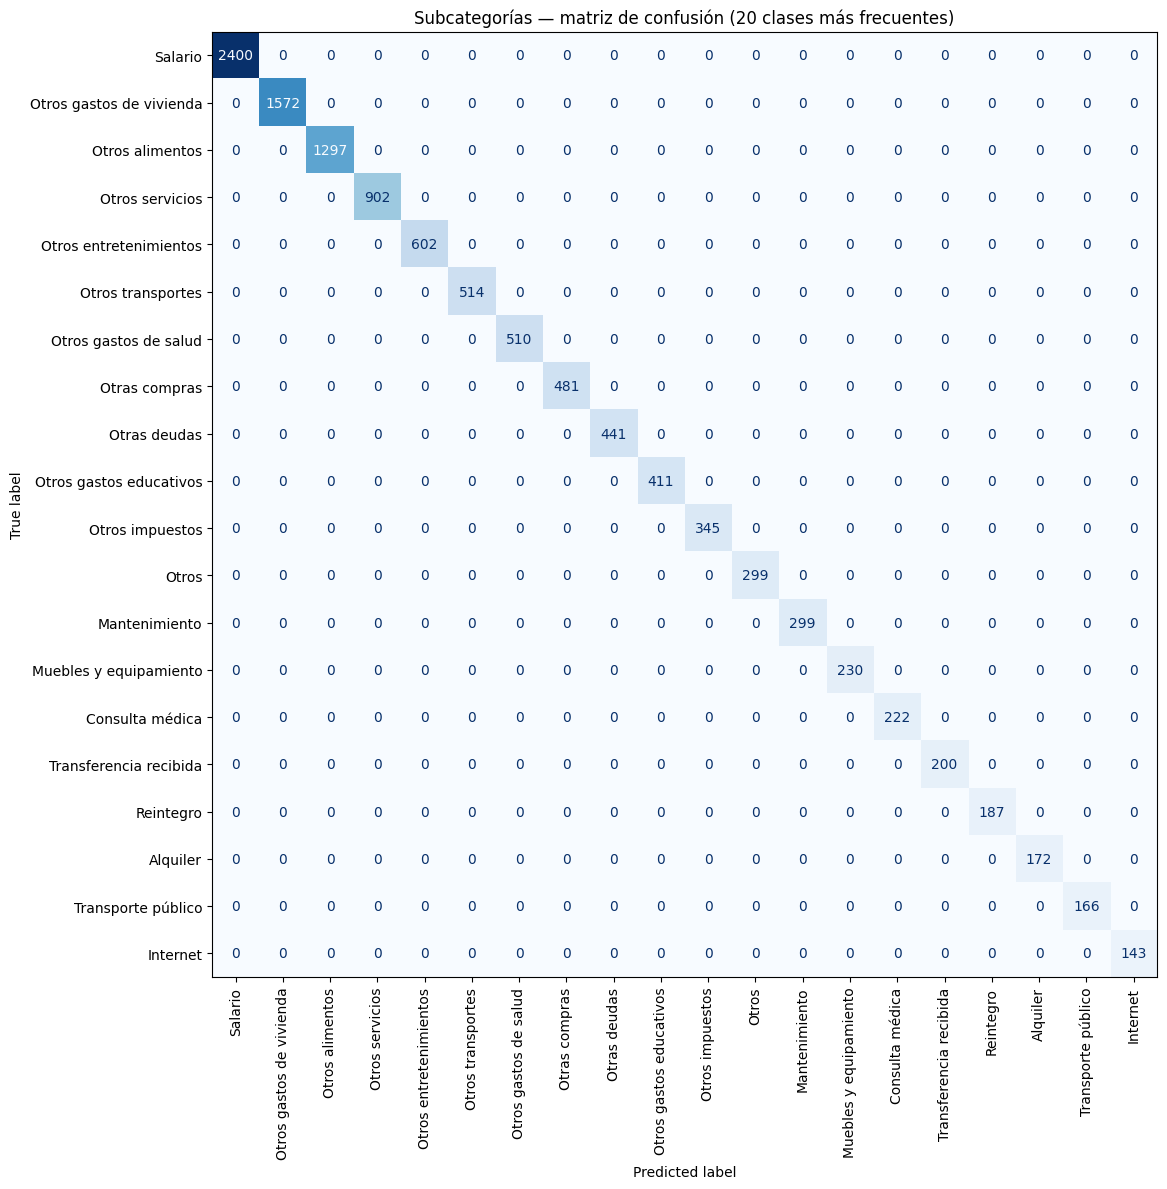


Modelo exportado en: /content/models/clasificador_subcategoria.joblib
{'subcategoria_predicha': 'Supermercado', 'confianza_subcategoria': 0.976408616887585}


In [44]:
# ============================================================
# CLASIFICADOR COMPLEMENTARIO DE SUBCATEGORÍAS
# ============================================================

from pathlib import Path
import re
import unicodedata
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Localiza el CSV sin modificar ni regenerar el dataset.
CANDIDATOS_TRANSACCIONES = [
    Path("data/raw/transacciones_sinteticas.csv"),
    Path("data/transacciones_sinteticas.csv"),
    Path("transacciones_sinteticas.csv"),
    Path("/mnt/data/transacciones_sinteticas(20260821-181442).csv"),
]

csv_transacciones = next((p for p in CANDIDATOS_TRANSACCIONES if p.exists()), None)
if csv_transacciones is None:
    raise FileNotFoundError(
        "No se encontró transacciones_sinteticas.csv. "
        "Ajustá CANDIDATOS_TRANSACCIONES a la ubicación del dataset actual."
    )

df_sub = pd.read_csv(csv_transacciones)

requeridas = {"usuario_id", "descripcion", "categoria", "subcategoria"}
faltantes = requeridas - set(df_sub.columns)
if faltantes:
    raise ValueError(f"Faltan columnas requeridas para subcategorías: {sorted(faltantes)}")

df_sub = df_sub.dropna(subset=list(requeridas)).copy()

def normalizar_texto_sub(texto):
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# La categoría forma parte de la entrada del segundo nivel jerárquico.
df_sub["texto_subcategoria"] = (
    df_sub["categoria"].map(normalizar_texto_sub)
    + " __cat__ "
    + df_sub["descripcion"].map(normalizar_texto_sub)
)

X_sub = df_sub["texto_subcategoria"]
y_sub = df_sub["subcategoria"].astype(str)
groups_sub = df_sub["usuario_id"].astype(str)

print(f"Transacciones: {len(df_sub):,}")
print(f"Categorías: {df_sub['categoria'].nunique()}")
print(f"Subcategorías: {y_sub.nunique()}")

# Hold-out agrupado por usuario.
gss_sub = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx_sub, test_idx_sub = next(gss_sub.split(X_sub, y_sub, groups=groups_sub))

X_train_sub, X_test_sub = X_sub.iloc[train_idx_sub], X_sub.iloc[test_idx_sub]
y_train_sub, y_test_sub = y_sub.iloc[train_idx_sub], y_sub.iloc[test_idx_sub]

usuarios_train_sub = set(groups_sub.iloc[train_idx_sub])
usuarios_test_sub = set(groups_sub.iloc[test_idx_sub])
assert usuarios_train_sub.isdisjoint(usuarios_test_sub)

modelo_subcategoria = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=2500,
        class_weight="balanced",
        random_state=42,
    )),
])

modelo_subcategoria.fit(X_train_sub, y_train_sub)
pred_sub = modelo_subcategoria.predict(X_test_sub)

acc_sub = accuracy_score(y_test_sub, pred_sub)
f1_sub = f1_score(y_test_sub, pred_sub, average="macro")

print("\n=== HOLD-OUT AGRUPADO POR USUARIO ===")
print(f"Train: {len(X_train_sub):,}")
print(f"Test: {len(X_test_sub):,}")
print(f"Usuarios compartidos: {len(usuarios_train_sub & usuarios_test_sub)}")
print(f"Accuracy: {acc_sub:.4f}")
print(f"F1 macro: {f1_sub:.4f}")
print("\n", classification_report(y_test_sub, pred_sub, zero_division=0))

# Evaluación adicional sobre categoría+descripción no vistas exactamente en train.
firmas_train = set(X_train_sub)
mask_no_vistas = ~X_test_sub.isin(firmas_train)

if mask_no_vistas.any():
    y_nv = y_test_sub[mask_no_vistas]
    pred_nv = modelo_subcategoria.predict(X_test_sub[mask_no_vistas])
    acc_nv = accuracy_score(y_nv, pred_nv)
    f1_nv = f1_score(y_nv, pred_nv, average="macro")

    print("\n=== DESCRIPCIONES NO VISTAS EN TRAIN ===")
    print(f"Casos: {mask_no_vistas.sum():,}")
    print(f"Accuracy: {acc_nv:.4f}")
    print(f"F1 macro: {f1_nv:.4f}")
else:
    print("\nNo hubo descripciones nuevas en el hold-out seleccionado.")

# CV agrupada: mantiene separados los usuarios entre folds.
cv_sub = GroupKFold(n_splits=5)
scores_cv_sub = cross_val_score(
    modelo_subcategoria,
    X_sub,
    y_sub,
    groups=groups_sub,
    cv=cv_sub,
    scoring="f1_macro",
    n_jobs=-1,
)

print("\n=== CV AGRUPADA POR USUARIO ===")
print("F1 macro por fold:", np.round(scores_cv_sub, 4))
print(f"F1 macro media: {scores_cv_sub.mean():.4f}")
print(f"Desvío: {scores_cv_sub.std():.4f}")

# Con 88 clases una matriz completa resulta poco legible.
# Se grafica la matriz para las subcategorías más frecuentes.
top_subcats = y_test_sub.value_counts().head(20).index.tolist()
mask_top = y_test_sub.isin(top_subcats)

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test_sub[mask_top],
    pred_sub[mask_top],
    labels=top_subcats,
    normalize=None,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Subcategorías — matriz de confusión (20 clases más frecuentes)")
plt.tight_layout()
plt.show()

# Reentrena sobre todo el dataset para generar el artefacto productivo.
modelo_subcategoria_final = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=2500,
        class_weight="balanced",
        random_state=42,
    )),
])
modelo_subcategoria_final.fit(X_sub, y_sub)

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBCAT_MODEL_PATH = MODEL_DIR / "clasificador_subcategoria.joblib"
joblib.dump(modelo_subcategoria_final, SUBCAT_MODEL_PATH)

print(f"\nModelo exportado en: {SUBCAT_MODEL_PATH.resolve()}")

def predecir_subcategoria(descripcion, categoria):
    """
    Segundo nivel del pipeline.
    Recibe la categoría ya predicha por el modelo principal y devuelve
    una subcategoría sin modificar el contrato del clasificador de categoría.
    """
    texto = (
        normalizar_texto_sub(categoria)
        + " __cat__ "
        + normalizar_texto_sub(descripcion)
    )
    probs = modelo_subcategoria_final.predict_proba([texto])[0]
    clases = modelo_subcategoria_final.classes_
    idx = int(np.argmax(probs))

    return {
        "subcategoria_predicha": str(clases[idx]),
        "confianza_subcategoria": float(probs[idx]),
    }

# Ejemplo rápido
print(predecir_subcategoria("Compra en supermercado", "Alimentación"))


### Integración con FinSightAI

Este clasificador es **aditivo**: no reemplaza el clasificador de categorías ni el
clasificador de perfil financiero y no modifica el comportamiento actual de Finsi.

En producción, el flujo esperado es:

1. El modelo actual predice `categoria`.
2. El clasificador complementario recibe `descripcion + categoria`.
3. Se agrega `subcategoria` a la transacción.
4. El resto del análisis financiero y Finsi continúan consumiendo el contrato actual.

La elevada métrica sobre datos sintéticos debe interpretarse considerando que el
generador produce patrones de descripción consistentes. Por ese motivo se mantienen
la separación por usuario y la evaluación adicional sobre descripciones no vistas.


## **27. Conclusiones**

El desarrollo de FinSightAI permitió construir un pipeline integral de Ciencia de Datos alineado con los objetivos del hackathon y con el alcance real del MVP.

El notebook implementa:

- exploración y validación de datos;
- procesamiento de variables financieras y textuales;
- ingeniería de atributos;
- clasificación automática de gastos e ingresos;
- análisis y clasificación del perfil financiero;
- entrenamiento y evaluación mediante métricas apropiadas;
- interpretabilidad de los modelos;
- generación de recomendaciones explicables;
- serialización de modelos y pipelines;
- contratos JSON compatibles con FastAPI.

El clasificador de transacciones utiliza principalmente la descripción normalizada para reconocer categorías financieras. El clasificador de perfil combina indicadores de endeudamiento, gastos, ahorro y comportamiento transaccional para caracterizar la situación económica del usuario.

La serialización de los pipelines completos garantiza que el mismo preprocesamiento utilizado durante el entrenamiento sea reutilizado durante la inferencia. Esto reduce inconsistencias entre el notebook y el AI-Service.

FinSightAI queda definido como una plataforma de análisis financiero asistida por IA. El sistema interpreta información, identifica patrones y genera recomendaciones, pero no administra dinero ni reemplaza el asesoramiento profesional.

El pipeline constituye una base sólida para futuras mejoras, entre ellas el entrenamiento con datos reales, la ampliación del vocabulario transaccional, la calibración de probabilidades y la evaluación continua de las recomendaciones.


## **28. Limitaciones**

El presente trabajo posee las siguientes limitaciones:

- Los datos utilizados son sintéticos y fueron generados para representar distintos comportamientos financieros.
- El desempeño observado debe validarse posteriormente con datos reales, externos e independientes.
- El clasificador de transacciones necesitará un vocabulario más amplio y diverso para generalizar a descripciones bancarias reales.
- Las categorías pueden presentar patrones textuales demasiado regulares en el dataset sintético, elevando artificialmente algunas métricas.
- Las recomendaciones y el score financiero se basan en reglas explicables diseñadas para el MVP y deberían revisarse con especialistas del dominio.
- El score constituye un indicador propio del proyecto; no es una calificación crediticia oficial.
- El perfil financiero resume patrones observados y no representa un diagnóstico profesional.
- El modelo puede reproducir sesgos presentes en los datos utilizados para su entrenamiento.
- La aplicación no administra dinero, cuentas, transferencias ni saldos bancarios.
- Antes de utilizar el sistema en producción será necesario implementar monitoreo, recalibración, control de deriva y protección de datos personales.
